In [122]:
import duckdb

con = duckdb.connect()

result = con.execute("""
    SELECT *
    FROM read_parquet('../data/processed/sales_processed.parquet')
    LIMIT 10
""").df()

print(result)

                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   
5  HOBBIES_1_006_CA_1_validation  HOBBIES_1_006  HOBBIES_1  HOBBIES     CA_1   
6  HOBBIES_1_007_CA_1_validation  HOBBIES_1_007  HOBBIES_1  HOBBIES     CA_1   
7  HOBBIES_1_008_CA_1_validation  HOBBIES_1_008  HOBBIES_1  HOBBIES     CA_1   
8  HOBBIES_1_009_CA_1_validation  HOBBIES_1_009  HOBBIES_1  HOBBIES     CA_1   
9  HOBBIES_1_010_CA_1_validation  HOBBIES_1_010  HOBBIES_1  HOBBIES     CA_1   

  state_id    d  sales       date  wm_yr_wk  ... event_type_1  event_name_2  \
0       CA  d_1      0 2011-01-29     11

In [123]:
# import pandas as pd
# sales=pd.read_parquet(
#     "../data/processed/sales_processed.parquet"
# )
# print(sales.shape)
# print(sales.head())

In [124]:
result=con.execute("""
    SELECT COUNT(*) AS total_rows
    FROM read_parquet('../data/processed/sales_processed.parquet')
""").df()
print(result)

   total_rows
0    58327370


In [125]:
schema = con.execute("""
    DESCRIBE
    SELECT *
    FROM read_parquet('../data/processed/sales_processed.parquet')
""").df()

print(schema)

     column_name column_type null   key default extra
0             id     VARCHAR  YES  None    None  None
1        item_id     VARCHAR  YES  None    None  None
2        dept_id     VARCHAR  YES  None    None  None
3         cat_id     VARCHAR  YES  None    None  None
4       store_id     VARCHAR  YES  None    None  None
5       state_id     VARCHAR  YES  None    None  None
6              d     VARCHAR  YES  None    None  None
7          sales      BIGINT  YES  None    None  None
8           date   TIMESTAMP  YES  None    None  None
9       wm_yr_wk      BIGINT  YES  None    None  None
10       weekday     VARCHAR  YES  None    None  None
11          wday      BIGINT  YES  None    None  None
12         month     INTEGER  YES  None    None  None
13          year     INTEGER  YES  None    None  None
14  event_name_1     VARCHAR  YES  None    None  None
15  event_type_1     VARCHAR  YES  None    None  None
16  event_name_2     VARCHAR  YES  None    None  None
17  event_type_2     VARCHAR

In [126]:
columns = con.execute("""
    SELECT *
    FROM read_parquet('../data/processed/sales_processed.parquet')
    LIMIT 1
""").df().columns

print(list(columns))

['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'week', 'day', 'dayofweek']


In [127]:
result = con.execute("""
    SELECT
        *,
        LAG(sales, 7) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_7
    FROM read_parquet('../data/processed/sales_processed.parquet')
    LIMIT 100
""").df()

print(result[[
    "item_id",
    "store_id",
    "date",
    "sales",
    "lag_7"
]].head(20))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

        item_id store_id       date  sales  lag_7
0   FOODS_1_030     WI_2 2011-01-29      0   <NA>
1   FOODS_1_030     WI_2 2011-01-30      0   <NA>
2   FOODS_1_030     WI_2 2011-01-31      0   <NA>
3   FOODS_1_030     WI_2 2011-02-01      0   <NA>
4   FOODS_1_030     WI_2 2011-02-02      0   <NA>
5   FOODS_1_030     WI_2 2011-02-03      0   <NA>
6   FOODS_1_030     WI_2 2011-02-04      0   <NA>
7   FOODS_1_030     WI_2 2011-02-05      0      0
8   FOODS_1_030     WI_2 2011-02-06      0      0
9   FOODS_1_030     WI_2 2011-02-07      0      0
10  FOODS_1_030     WI_2 2011-02-08      0      0
11  FOODS_1_030     WI_2 2011-02-09      0      0
12  FOODS_1_030     WI_2 2011-02-10      0      0
13  FOODS_1_030     WI_2 2011-02-11      0      0
14  FOODS_1_030     WI_2 2011-02-12      0      0
15  FOODS_1_030     WI_2 2011-02-13      0      0
16  FOODS_1_030     WI_2 2011-02-14      0      0
17  FOODS_1_030     WI_2 2011-02-15      0      0
18  FOODS_1_030     WI_2 2011-02-16      0      0


In [128]:
result = con.execute("""
    SELECT
        item_id,
        store_id,
        date,
        sales,
        LAG(sales, 7) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_7
    FROM read_parquet('../data/processed/sales_processed.parquet')
    WHERE item_id = 'HOBBIES_1_001'
      AND store_id = 'CA_1'
    ORDER BY date
""").df()

print(result.head(20))

          item_id store_id       date  sales  lag_7
0   HOBBIES_1_001     CA_1 2011-01-29      0   <NA>
1   HOBBIES_1_001     CA_1 2011-01-30      0   <NA>
2   HOBBIES_1_001     CA_1 2011-01-31      0   <NA>
3   HOBBIES_1_001     CA_1 2011-02-01      0   <NA>
4   HOBBIES_1_001     CA_1 2011-02-02      0   <NA>
5   HOBBIES_1_001     CA_1 2011-02-03      0   <NA>
6   HOBBIES_1_001     CA_1 2011-02-04      0   <NA>
7   HOBBIES_1_001     CA_1 2011-02-05      0      0
8   HOBBIES_1_001     CA_1 2011-02-06      0      0
9   HOBBIES_1_001     CA_1 2011-02-07      0      0
10  HOBBIES_1_001     CA_1 2011-02-08      0      0
11  HOBBIES_1_001     CA_1 2011-02-09      0      0
12  HOBBIES_1_001     CA_1 2011-02-10      0      0
13  HOBBIES_1_001     CA_1 2011-02-11      0      0
14  HOBBIES_1_001     CA_1 2011-02-12      0      0
15  HOBBIES_1_001     CA_1 2011-02-13      0      0
16  HOBBIES_1_001     CA_1 2011-02-14      0      0
17  HOBBIES_1_001     CA_1 2011-02-15      0      0
18  HOBBIES_

In [129]:
result = con.execute("""
    SELECT
        item_id,
        store_id,
        date,
        sales,
        LAG(sales, 1) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_1
    FROM read_parquet('../data/processed/sales_processed.parquet')
    WHERE item_id = 'HOBBIES_1_001'
      AND store_id = 'CA_1'
    ORDER BY date
""").df()

print(result.head(15))

          item_id store_id       date  sales  lag_1
0   HOBBIES_1_001     CA_1 2011-01-29      0   <NA>
1   HOBBIES_1_001     CA_1 2011-01-30      0      0
2   HOBBIES_1_001     CA_1 2011-01-31      0      0
3   HOBBIES_1_001     CA_1 2011-02-01      0      0
4   HOBBIES_1_001     CA_1 2011-02-02      0      0
5   HOBBIES_1_001     CA_1 2011-02-03      0      0
6   HOBBIES_1_001     CA_1 2011-02-04      0      0
7   HOBBIES_1_001     CA_1 2011-02-05      0      0
8   HOBBIES_1_001     CA_1 2011-02-06      0      0
9   HOBBIES_1_001     CA_1 2011-02-07      0      0
10  HOBBIES_1_001     CA_1 2011-02-08      0      0
11  HOBBIES_1_001     CA_1 2011-02-09      0      0
12  HOBBIES_1_001     CA_1 2011-02-10      0      0
13  HOBBIES_1_001     CA_1 2011-02-11      0      0
14  HOBBIES_1_001     CA_1 2011-02-12      0      0


In [130]:
result = con.execute("""
    SELECT
        item_id,
        store_id,
        date,
        sales,

        LAG(sales, 7) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_7,

        LAG(sales, 14) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_14

    FROM read_parquet('../data/processed/sales_processed.parquet')

    WHERE item_id = 'HOBBIES_1_001'
      AND store_id = 'CA_1'

    ORDER BY date
""").df()

print(result.head(20))

          item_id store_id       date  sales  lag_7  lag_14
0   HOBBIES_1_001     CA_1 2011-01-29      0   <NA>    <NA>
1   HOBBIES_1_001     CA_1 2011-01-30      0   <NA>    <NA>
2   HOBBIES_1_001     CA_1 2011-01-31      0   <NA>    <NA>
3   HOBBIES_1_001     CA_1 2011-02-01      0   <NA>    <NA>
4   HOBBIES_1_001     CA_1 2011-02-02      0   <NA>    <NA>
5   HOBBIES_1_001     CA_1 2011-02-03      0   <NA>    <NA>
6   HOBBIES_1_001     CA_1 2011-02-04      0   <NA>    <NA>
7   HOBBIES_1_001     CA_1 2011-02-05      0      0    <NA>
8   HOBBIES_1_001     CA_1 2011-02-06      0      0    <NA>
9   HOBBIES_1_001     CA_1 2011-02-07      0      0    <NA>
10  HOBBIES_1_001     CA_1 2011-02-08      0      0    <NA>
11  HOBBIES_1_001     CA_1 2011-02-09      0      0    <NA>
12  HOBBIES_1_001     CA_1 2011-02-10      0      0    <NA>
13  HOBBIES_1_001     CA_1 2011-02-11      0      0    <NA>
14  HOBBIES_1_001     CA_1 2011-02-12      0      0       0
15  HOBBIES_1_001     CA_1 2011-02-13   

In [131]:
result = con.execute("""
    SELECT *
    FROM read_parquet('../data/processed/sales_processed.parquet')
    WHERE store_id = 'CA_1'
    ORDER BY item_id, date
""").df()

print(result.shape)
print(result.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

MemoryError: Unable to allocate 267. MiB for an array with shape (6, 5832737) and data type int64

In [ ]:
result = con.execute("""
    SELECT
        item_id,
        store_id,
        date,
        sales,
        sell_price,
        dayofweek,
        month,
        year
    FROM read_parquet('../data/processed/sales_processed.parquet')
    WHERE item_id = 'HOBBIES_1_001'
      AND store_id = 'CA_1'
    ORDER BY date
""").df()

print(result.shape)
print(result.head())

(1913, 8)
         item_id store_id       date  sales  sell_price  dayofweek  month  \
0  HOBBIES_1_001     CA_1 2011-01-29      0         NaN          5      1   
1  HOBBIES_1_001     CA_1 2011-01-30      0         NaN          6      1   
2  HOBBIES_1_001     CA_1 2011-01-31      0         NaN          0      1   
3  HOBBIES_1_001     CA_1 2011-02-01      0         NaN          1      2   
4  HOBBIES_1_001     CA_1 2011-02-02      0         NaN          2      2   

   year  
0  2011  
1  2011  
2  2011  
3  2011  
4  2011  


In [ ]:
result = con.execute("""
    SELECT
        item_id,
        store_id,
        date,
        sales,

        LAG(sales, 1) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_1,

        LAG(sales, 7) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_7,

        LAG(sales, 14) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_14

    FROM read_parquet('../data/processed/sales_processed.parquet')

    WHERE item_id = 'HOBBIES_1_001'
      AND store_id = 'CA_1'

    ORDER BY date
""").df()

print(result.head(20))

          item_id store_id       date  sales  lag_1  lag_7  lag_14
0   HOBBIES_1_001     CA_1 2011-01-29      0   <NA>   <NA>    <NA>
1   HOBBIES_1_001     CA_1 2011-01-30      0      0   <NA>    <NA>
2   HOBBIES_1_001     CA_1 2011-01-31      0      0   <NA>    <NA>
3   HOBBIES_1_001     CA_1 2011-02-01      0      0   <NA>    <NA>
4   HOBBIES_1_001     CA_1 2011-02-02      0      0   <NA>    <NA>
5   HOBBIES_1_001     CA_1 2011-02-03      0      0   <NA>    <NA>
6   HOBBIES_1_001     CA_1 2011-02-04      0      0   <NA>    <NA>
7   HOBBIES_1_001     CA_1 2011-02-05      0      0      0    <NA>
8   HOBBIES_1_001     CA_1 2011-02-06      0      0      0    <NA>
9   HOBBIES_1_001     CA_1 2011-02-07      0      0      0    <NA>
10  HOBBIES_1_001     CA_1 2011-02-08      0      0      0    <NA>
11  HOBBIES_1_001     CA_1 2011-02-09      0      0      0    <NA>
12  HOBBIES_1_001     CA_1 2011-02-10      0      0      0    <NA>
13  HOBBIES_1_001     CA_1 2011-02-11      0      0      0    

In [ ]:
print(result[["date", "sales", "lag_1", "lag_7", "lag_14"]].head(40))

         date  sales  lag_1  lag_7  lag_14
0  2011-01-29      0   <NA>   <NA>    <NA>
1  2011-01-30      0      0   <NA>    <NA>
2  2011-01-31      0      0   <NA>    <NA>
3  2011-02-01      0      0   <NA>    <NA>
4  2011-02-02      0      0   <NA>    <NA>
5  2011-02-03      0      0   <NA>    <NA>
6  2011-02-04      0      0   <NA>    <NA>
7  2011-02-05      0      0      0    <NA>
8  2011-02-06      0      0      0    <NA>
9  2011-02-07      0      0      0    <NA>
10 2011-02-08      0      0      0    <NA>
11 2011-02-09      0      0      0    <NA>
12 2011-02-10      0      0      0    <NA>
13 2011-02-11      0      0      0    <NA>
14 2011-02-12      0      0      0       0
15 2011-02-13      0      0      0       0
16 2011-02-14      0      0      0       0
17 2011-02-15      0      0      0       0
18 2011-02-16      0      0      0       0
19 2011-02-17      0      0      0       0
20 2011-02-18      0      0      0       0
21 2011-02-19      0      0      0       0
22 2011-02-

In [ ]:
result = con.execute("""
    SELECT
        item_id,
        store_id,
        date,
        sales,

        LAG(sales, 1) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_1,

        LAG(sales, 7) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_7,

        LAG(sales, 14) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_14,

        AVG(sales) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS rolling_mean_7,

        AVG(sales) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
            ROWS BETWEEN 28 PRECEDING AND 1 PRECEDING
        ) AS rolling_mean_28

    FROM read_parquet('../data/processed/sales_processed.parquet')

    WHERE item_id = 'HOBBIES_1_001'
      AND store_id = 'CA_1'

    ORDER BY date
""").df()

print(result[[
    "date",
    "sales",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_28"
]].head(35))

         date  sales  lag_1  lag_7  lag_14  rolling_mean_7  rolling_mean_28
0  2011-01-29      0   <NA>   <NA>    <NA>             NaN              NaN
1  2011-01-30      0      0   <NA>    <NA>             0.0              0.0
2  2011-01-31      0      0   <NA>    <NA>             0.0              0.0
3  2011-02-01      0      0   <NA>    <NA>             0.0              0.0
4  2011-02-02      0      0   <NA>    <NA>             0.0              0.0
5  2011-02-03      0      0   <NA>    <NA>             0.0              0.0
6  2011-02-04      0      0   <NA>    <NA>             0.0              0.0
7  2011-02-05      0      0      0    <NA>             0.0              0.0
8  2011-02-06      0      0      0    <NA>             0.0              0.0
9  2011-02-07      0      0      0    <NA>             0.0              0.0
10 2011-02-08      0      0      0    <NA>             0.0              0.0
11 2011-02-09      0      0      0    <NA>             0.0              0.0
12 2011-02-1

In [ ]:
result_clean = result.dropna()

print("Before:", result.shape)
print("After :", result_clean.shape)

print(result_clean.head())

Before: (1913, 9)
After : (1899, 9)
          item_id store_id       date  sales  lag_1  lag_7  lag_14  \
14  HOBBIES_1_001     CA_1 2011-02-12      0      0      0       0   
15  HOBBIES_1_001     CA_1 2011-02-13      0      0      0       0   
16  HOBBIES_1_001     CA_1 2011-02-14      0      0      0       0   
17  HOBBIES_1_001     CA_1 2011-02-15      0      0      0       0   
18  HOBBIES_1_001     CA_1 2011-02-16      0      0      0       0   

    rolling_mean_7  rolling_mean_28  
14             0.0              0.0  
15             0.0              0.0  
16             0.0              0.0  
17             0.0              0.0  
18             0.0              0.0  


In [ ]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_28"
]

X = result_clean[features]
y = result_clean["sales"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

X shape: (1899, 5)
y shape: (1899,)

X:
    lag_1  lag_7  lag_14  rolling_mean_7  rolling_mean_28
14      0      0       0             0.0              0.0
15      0      0       0             0.0              0.0
16      0      0       0             0.0              0.0
17      0      0       0             0.0              0.0
18      0      0       0             0.0              0.0

y:
14    0
15    0
16    0
17    0
18    0
Name: sales, dtype: int64


In [ ]:
split_date = "2016-04-01"

train = result_clean[result_clean["date"] < split_date]
test = result_clean[result_clean["date"] >= split_date]

print("Train shape:", train.shape)
print("Test shape :", test.shape)

print("\nTrain dates:")
print(train["date"].min(), "to", train["date"].max())

print("\nTest dates:")
print(test["date"].min(), "to", test["date"].max())

Train shape: (1875, 9)
Test shape : (24, 9)

Train dates:
2011-02-12 00:00:00 to 2016-03-31 00:00:00

Test dates:
2016-04-01 00:00:00 to 2016-04-24 00:00:00


In [ ]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_28"
]

X_train = train[features]
y_train = train["sales"]

X_test = test[features]
y_test = test["sales"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (1875, 5)
y_train: (1875,)
X_test : (24, 5)
y_test : (24,)


Historical data
      ↓
Lag + rolling features
      ↓
Time-based split
      ↓
 ┌──────────────┐
 │   X_train    │ ──→ MODEL ──→ predictions
 │   y_train    │
 └──────────────┘
                         ↓
                    compare with
                         ↓
                      y_test

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np
baseline_pred=X_test["lag_1"]
mae=mean_absolute_error(y_test,baseline_pred)
rmse=np.sqrt(mean_squared_error(y_test,baseline_pred))
print("Baseline MAE :",mae)
print("Baseline MAE :",rmse)

Baseline MAE : 1.2083333333333333
Baseline MAE : 1.6708281379802852


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np
model=RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train,y_train)
ml_pred=model.predict(X_test)
mae = mean_absolute_error(y_test, ml_pred)
rmse = np.sqrt(mean_squared_error(y_test, ml_pred))

print("Random Forest MAE :", mae)
print("Random Forest RMSE:", rmse)

Random Forest MAE : 0.8969374999999999
Random Forest RMSE: 1.1126682566270845


In [ ]:
import pandas as pd
comparison = pd.DataFrame({
    "date": test["date"].values,
    "actual": y_test.values,
    "baseline": baseline_pred.values,
    "random_forest": ml_pred
})

print(comparison.head(20))

         date  actual  baseline  random_forest
0  2016-04-01       0         0       0.530000
1  2016-04-02       0         0       0.676500
2  2016-04-03       1         0       0.525000
3  2016-04-04       0         1       0.483333
4  2016-04-05       4         0       0.781667
5  2016-04-06       2         4       1.650000
6  2016-04-07       3         2       1.290000
7  2016-04-08       0         3       0.790000
8  2016-04-09       1         0       0.960000
9  2016-04-10       2         1       0.940000
10 2016-04-11       0         2       1.030000
11 2016-04-12       0         0       0.730000
12 2016-04-13       0         0       0.883333
13 2016-04-14       1         0       1.170000
14 2016-04-15       1         1       1.520000
15 2016-04-16       3         1       1.500000
16 2016-04-17       0         3       0.910000
17 2016-04-18       1         0       0.110000
18 2016-04-19       1         1       0.360000
19 2016-04-20       1         1       1.540000


In [ ]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

           feature  importance
4  rolling_mean_28    0.458107
3   rolling_mean_7    0.229196
2           lag_14    0.116780
0            lag_1    0.100540
1            lag_7    0.095378


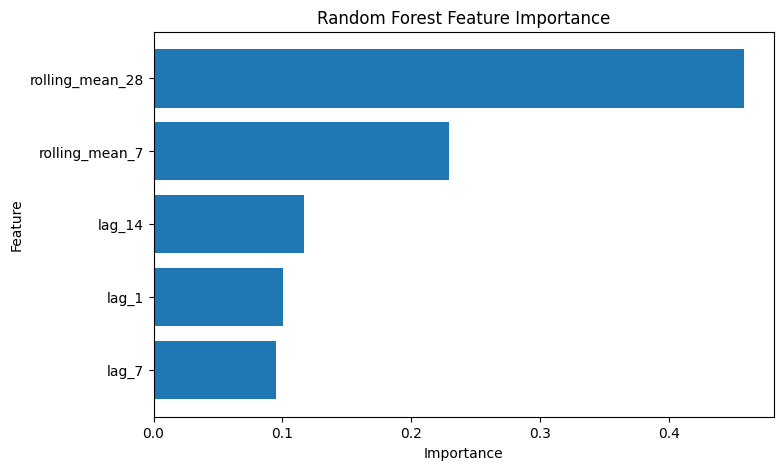

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
model_300 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model_300.fit(X_train, y_train)

pred_300 = model_300.predict(X_test)

mae_300 = mean_absolute_error(y_test, pred_300)
rmse_300 = np.sqrt(mean_squared_error(y_test, pred_300))

print("Random Forest 300 trees")
print("MAE :", mae_300)
print("RMSE:", rmse_300)

Random Forest 300 trees
MAE : 0.9250524691358025
RMSE: 1.1323226043572403


In [ ]:
import joblib
joblib.dump(model,"../models/random_forest_best.pkl")
print("Best model saved")

Best model saved


In [ ]:
result["dayofweek"] = result["date"].dt.dayofweek
result["month"] = result["date"].dt.month
result["year"] = result["date"].dt.year

print(result.columns)

Index(['item_id', 'store_id', 'date', 'sales', 'lag_1', 'lag_7', 'lag_14',
       'rolling_mean_7', 'rolling_mean_28', 'dayofweek', 'month', 'year'],
      dtype='str')


In [ ]:
calendar_features=["dayofweek","month","year"]
features_v2=[
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_28",
    "dayofweek",
    "month",
    "year"]
result_v2=result.dropna()
train_v2=result_v2[result_v2["date"]<split_date]
test_v2=result_v2[result_v2["date"]>=split_date]

X_train_v2 = train_v2[features_v2]
y_train_v2 = train_v2["sales"]

X_test_v2 = test_v2[features_v2]
y_test_v2 = test_v2["sales"]

print(X_train_v2.shape)
print(X_test_v2.shape)

(1875, 8)
(24, 8)


In [ ]:
model_v2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_train_v2, y_train_v2)

pred_v2 = model_v2.predict(X_test_v2)

mae_v2 = mean_absolute_error(y_test_v2, pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, pred_v2))

print("Random Forest V2")
print("MAE :", mae_v2)
print("RMSE:", rmse_v2)

Random Forest V2
MAE : 0.9016666666666667
RMSE: 1.130932506091028


In [ ]:
print(result.columns)

Index(['item_id', 'store_id', 'date', 'sales', 'lag_1', 'lag_7', 'lag_14',
       'rolling_mean_7', 'rolling_mean_28', 'dayofweek', 'month', 'year'],
      dtype='str')


In [ ]:
result = con.execute("""
    SELECT
        item_id,
        store_id,
        date,
        sales,
        sell_price,

        LAG(sales, 1) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_1,

        LAG(sales, 7) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_7,

        LAG(sales, 14) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_14,

        AVG(sales) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS rolling_mean_7,

        AVG(sales) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
            ROWS BETWEEN 28 PRECEDING AND 1 PRECEDING
        ) AS rolling_mean_28

    FROM read_parquet('../data/processed/sales_processed.parquet')
    WHERE item_id = 'HOBBIES_1_001'
      AND store_id = 'CA_1'
    ORDER BY date
""").df()

print(result.columns)

Index(['item_id', 'store_id', 'date', 'sales', 'sell_price', 'lag_1', 'lag_7',
       'lag_14', 'rolling_mean_7', 'rolling_mean_28'],
      dtype='str')


In [ ]:
print(
    con.execute("""
        DESCRIBE
        SELECT *
        FROM read_parquet('../data/processed/sales_processed.parquet')
    """).df()
)

     column_name column_type null   key default extra
0             id     VARCHAR  YES  None    None  None
1        item_id     VARCHAR  YES  None    None  None
2        dept_id     VARCHAR  YES  None    None  None
3         cat_id     VARCHAR  YES  None    None  None
4       store_id     VARCHAR  YES  None    None  None
5       state_id     VARCHAR  YES  None    None  None
6              d     VARCHAR  YES  None    None  None
7          sales      BIGINT  YES  None    None  None
8           date   TIMESTAMP  YES  None    None  None
9       wm_yr_wk      BIGINT  YES  None    None  None
10       weekday     VARCHAR  YES  None    None  None
11          wday      BIGINT  YES  None    None  None
12         month     INTEGER  YES  None    None  None
13          year     INTEGER  YES  None    None  None
14  event_name_1     VARCHAR  YES  None    None  None
15  event_type_1     VARCHAR  YES  None    None  None
16  event_name_2     VARCHAR  YES  None    None  None
17  event_type_2     VARCHAR

In [ ]:
result = con.execute("""
    SELECT
        item_id,
        store_id,
        date,
        sales,
        sell_price,

        LAG(sales, 1) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_1,

        LAG(sales, 7) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_7,

        LAG(sales, 14) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_14,

        AVG(sales) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS rolling_mean_7,

        AVG(sales) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
            ROWS BETWEEN 28 PRECEDING AND 1 PRECEDING
        ) AS rolling_mean_28

    FROM read_parquet('../data/processed/sales_processed.parquet')
    WHERE item_id = 'HOBBIES_1_001'
      AND store_id = 'CA_1'
    ORDER BY date
""").df()

result["dayofweek"] = result["date"].dt.dayofweek
result["month"] = result["date"].dt.month
result["year"] = result["date"].dt.year

print(result.columns)

Index(['item_id', 'store_id', 'date', 'sales', 'sell_price', 'lag_1', 'lag_7',
       'lag_14', 'rolling_mean_7', 'rolling_mean_28', 'dayofweek', 'month',
       'year'],
      dtype='str')


In [ ]:
features_v3 = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_28",
    "sell_price"
]

result_v3 = result.dropna()

train_v3 = result_v3[result_v3["date"] < split_date]
test_v3 = result_v3[result_v3["date"] >= split_date]

X_train_v3 = train_v3[features_v3]
y_train_v3 = train_v3["sales"]

X_test_v3 = test_v3[features_v3]
y_test_v3 = test_v3["sales"]

model_v3 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_v3.fit(X_train_v3, y_train_v3)

pred_v3 = model_v3.predict(X_test_v3)

mae_v3 = mean_absolute_error(y_test_v3, pred_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_test_v3, pred_v3))

print("Random Forest V3 + Price")
print("MAE :", mae_v3)
print("RMSE:", rmse_v3)

Random Forest V3 + Price
MAE : 0.8966180555555555
RMSE: 1.1233603117639042


In [ ]:
comparison_models = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest V1",
        "Random Forest V2 + Calendar",
        "Random Forest V3 + Price"
    ],
    "MAE": [
        1.2083,
        0.8969,
        mae_v2,
        mae_v3
    ],
    "RMSE": [
        1.6708,
        1.1127,
        rmse_v2,
        rmse_v3
    ]
})

print(comparison_models)

                         Model       MAE      RMSE
0               Naive Baseline  1.208300  1.670800
1             Random Forest V1  0.896900  1.112700
2  Random Forest V2 + Calendar  0.901667  1.130933
3     Random Forest V3 + Price  0.896618  1.123360


In [ ]:
experiment_results = pd.DataFrame({
    "experiment": [
        "Naive Baseline",
        "Random Forest V1",
        "Random Forest V2 + Calendar",
        "Random Forest V3 + Price"
    ],
    "MAE": [
        1.2083,
        0.8969,
        mae_v2,
        mae_v3
    ],
    "RMSE": [
        1.6708,
        1.1127,
        rmse_v2,
        rmse_v3
    ]
})

experiment_results.to_csv(
    "../models/experiment_results.csv",
    index=False
)

print("Experiment results saved.")

Experiment results saved.


In [ ]:
result["lag_28"] = con.execute("""
    SELECT
        LAG(sales, 28) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_28
    FROM read_parquet('../data/processed/sales_processed.parquet')
    WHERE item_id = 'HOBBIES_1_001'
      AND store_id = 'CA_1'
    ORDER BY date
""").df()["lag_28"]

print(result[["date", "sales", "lag_7", "lag_28"]].head(35))

         date  sales  lag_7  lag_28
0  2011-01-29      0   <NA>    <NA>
1  2011-01-30      0   <NA>    <NA>
2  2011-01-31      0   <NA>    <NA>
3  2011-02-01      0   <NA>    <NA>
4  2011-02-02      0   <NA>    <NA>
5  2011-02-03      0   <NA>    <NA>
6  2011-02-04      0   <NA>    <NA>
7  2011-02-05      0      0    <NA>
8  2011-02-06      0      0    <NA>
9  2011-02-07      0      0    <NA>
10 2011-02-08      0      0    <NA>
11 2011-02-09      0      0    <NA>
12 2011-02-10      0      0    <NA>
13 2011-02-11      0      0    <NA>
14 2011-02-12      0      0    <NA>
15 2011-02-13      0      0    <NA>
16 2011-02-14      0      0    <NA>
17 2011-02-15      0      0    <NA>
18 2011-02-16      0      0    <NA>
19 2011-02-17      0      0    <NA>
20 2011-02-18      0      0    <NA>
21 2011-02-19      0      0    <NA>
22 2011-02-20      0      0    <NA>
23 2011-02-21      0      0    <NA>
24 2011-02-22      0      0    <NA>
25 2011-02-23      0      0    <NA>
26 2011-02-24      0      0 

In [ ]:
features_v4 = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28"
]

result_v4 = result.dropna()

train_v4 = result_v4[result_v4["date"] < split_date]
test_v4 = result_v4[result_v4["date"] >= split_date]

X_train_v4 = train_v4[features_v4]
y_train_v4 = train_v4["sales"]

X_test_v4 = test_v4[features_v4]
y_test_v4 = test_v4["sales"]

model_v4 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_v4.fit(X_train_v4, y_train_v4)

pred_v4 = model_v4.predict(X_test_v4)

mae_v4 = mean_absolute_error(y_test_v4, pred_v4)
rmse_v4 = np.sqrt(mean_squared_error(y_test_v4, pred_v4))

print("Random Forest V4 + Lag 28")
print("MAE :", mae_v4)
print("RMSE:", rmse_v4)

Random Forest V4 + Lag 28
MAE : 0.8822916666666667
RMSE: 1.0852197784746613


In [ ]:
importance_v4 = pd.DataFrame({
    "feature": features_v4,
    "importance": model_v4.feature_importances_
})

importance_v4 = importance_v4.sort_values(
    "importance",
    ascending=False
)

print(importance_v4)

           feature  importance
5  rolling_mean_28    0.311121
4   rolling_mean_7    0.223371
2           lag_14    0.131846
3           lag_28    0.126313
0            lag_1    0.106221
1            lag_7    0.101128


In [ ]:
import joblib

joblib.dump(model_v4, "../models/random_forest_best.pkl")

print("V4 saved as the new best model.")

V4 saved as the new best model.


In [ ]:
pairs=con.execute("""
    SELECT DISTINCT item_id,store_id
    FROM read_parquet('../data/processed/sales_processed.parquet')
    WHERE item_id IN(
        'HOBBIES_1_001',
        'HOBBIES_1_002',
        'HOBBIES_1_003',
        'HOBBIES_1_004',
        'HOBBIES_1_005'
    )
    AND store_id IN (
        'CA_1',
        'CA_2',
        'CA_3'
    )
""").df()
print(pairs)
print("Number of product-store pairs:", len(pairs))

          item_id store_id
0   HOBBIES_1_002     CA_1
1   HOBBIES_1_002     CA_2
2   HOBBIES_1_004     CA_1
3   HOBBIES_1_004     CA_2
4   HOBBIES_1_003     CA_1
5   HOBBIES_1_003     CA_2
6   HOBBIES_1_002     CA_3
7   HOBBIES_1_005     CA_3
8   HOBBIES_1_003     CA_3
9   HOBBIES_1_001     CA_3
10  HOBBIES_1_005     CA_1
11  HOBBIES_1_005     CA_2
12  HOBBIES_1_001     CA_1
13  HOBBIES_1_001     CA_2
14  HOBBIES_1_004     CA_3
Number of product-store pairs: 15


In [ ]:
result_multi = con.execute("""
    SELECT
        item_id,
        store_id,
        date,
        sales,

        LAG(sales, 1) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_1,

        LAG(sales, 7) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_7,

        LAG(sales, 14) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_14,

        LAG(sales, 28) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
        ) AS lag_28,

        AVG(sales) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
            ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
        ) AS rolling_mean_7,

        AVG(sales) OVER (
            PARTITION BY item_id, store_id
            ORDER BY date
            ROWS BETWEEN 28 PRECEDING AND 1 PRECEDING
        ) AS rolling_mean_28

    FROM read_parquet('../data/processed/sales_processed.parquet')

    WHERE item_id IN (
        'HOBBIES_1_001',
        'HOBBIES_1_002',
        'HOBBIES_1_003',
        'HOBBIES_1_004',
        'HOBBIES_1_005'
    )

    AND store_id IN (
        'CA_1',
        'CA_2',
        'CA_3'
    )

    ORDER BY item_id, store_id, date
""").df()

print(result_multi.shape)
print(result_multi.head())

(28695, 10)
         item_id store_id       date  sales  lag_1  lag_7  lag_14  lag_28  \
0  HOBBIES_1_001     CA_1 2011-01-29      0   <NA>   <NA>    <NA>    <NA>   
1  HOBBIES_1_001     CA_1 2011-01-30      0      0   <NA>    <NA>    <NA>   
2  HOBBIES_1_001     CA_1 2011-01-31      0      0   <NA>    <NA>    <NA>   
3  HOBBIES_1_001     CA_1 2011-02-01      0      0   <NA>    <NA>    <NA>   
4  HOBBIES_1_001     CA_1 2011-02-02      0      0   <NA>    <NA>    <NA>   

   rolling_mean_7  rolling_mean_28  
0             NaN              NaN  
1             0.0              0.0  
2             0.0              0.0  
3             0.0              0.0  
4             0.0              0.0  


In [ ]:
result_multi_clean = result_multi.dropna()

print("Before:", result_multi.shape)
print("After :", result_multi_clean.shape)
print("Missing values:")
print(result_multi_clean.isna().sum())

Before: (28695, 10)
After : (28275, 10)
Missing values:
item_id            0
store_id           0
date               0
sales              0
lag_1              0
lag_7              0
lag_14             0
lag_28             0
rolling_mean_7     0
rolling_mean_28    0
dtype: int64


In [ ]:
split_date = "2016-04-01"

train_multi = result_multi_clean[
    result_multi_clean["date"] < split_date
]

test_multi = result_multi_clean[
    result_multi_clean["date"] >= split_date
]

print("Train shape:", train_multi.shape)
print("Test shape :", test_multi.shape)

print("\nTrain dates:")
print(train_multi["date"].min(), "to", train_multi["date"].max())

print("\nTest dates:")
print(test_multi["date"].min(), "to", test_multi["date"].max())

Train shape: (27915, 10)
Test shape : (360, 10)

Train dates:
2011-02-26 00:00:00 to 2016-03-31 00:00:00

Test dates:
2016-04-01 00:00:00 to 2016-04-24 00:00:00


In [ ]:
features_v4 = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28"
]
X_train_multi=train_multi[features_v4]
y_train_multi = train_multi["sales"]

X_test_multi = test_multi[features_v4]
y_test_multi = test_multi["sales"]

model_multi = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_multi.fit(X_train_multi, y_train_multi)

pred_multi = model_multi.predict(X_test_multi)

mae_multi = mean_absolute_error(
    y_test_multi,
    pred_multi
)

rmse_multi = np.sqrt(
    mean_squared_error(
        y_test_multi,
        pred_multi
    )
)

print("Multi-pair Random Forest V4")
print("MAE :", mae_multi)
print("RMSE:", rmse_multi)

Multi-pair Random Forest V4
MAE : 1.0654585071344096
RMSE: 1.616035380153158


In [ ]:
baseline_multi_pred = test_multi["lag_1"]

baseline_mae_multi = mean_absolute_error(
    y_test_multi,
    baseline_multi_pred
)

baseline_rmse_multi = np.sqrt(
    mean_squared_error(
        y_test_multi,
        baseline_multi_pred
    )
)

print("Multi-pair Naive Baseline")
print("MAE :", baseline_mae_multi)
print("RMSE:", baseline_rmse_multi)

Multi-pair Naive Baseline
MAE : 1.2527777777777778
RMSE: 2.0783273188899876


In [ ]:
mae_improvement = (
    (baseline_mae_multi - mae_multi)
    / baseline_mae_multi
) * 100

rmse_improvement = (
    (baseline_rmse_multi - rmse_multi)
    / baseline_rmse_multi
) * 100

print(f"MAE improvement : {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement : 14.95%
RMSE improvement: 22.24%


In [ ]:
multi_result = pd.DataFrame({
    "experiment": [
        "Multi-pair Naive Baseline",
        "Multi-pair Random Forest V4"
    ],
    "MAE": [
        baseline_mae_multi,
        mae_multi
    ],
    "RMSE": [
        baseline_rmse_multi,
        rmse_multi
    ]
})

multi_result.to_csv(
    "../models/multi_pair_results.csv",
    index=False
)

print(multi_result)
print("\nMulti-pair experiment saved.")

                    experiment       MAE      RMSE
0    Multi-pair Naive Baseline  1.252778  2.078327
1  Multi-pair Random Forest V4  1.065459  1.616035

Multi-pair experiment saved.


In [ ]:
from xgboost import XGBRegressor
xgb_model=XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train_multi,
    y_train_multi
)
xgb_pred=xgb_model.predict(X_test_multi)
xgb_mae = mean_absolute_error(
    y_test_multi,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_multi,
        xgb_pred
    )
)

print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)

XGBoost
MAE : 1.0324763059616089
RMSE: 1.5905904679962386


In [ ]:
importance_xgb = pd.DataFrame({
    "feature": features_v4,
    "importance": xgb_model.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    "importance",
    ascending=False
)

print(importance_xgb)

           feature  importance
5  rolling_mean_28    0.488903
4   rolling_mean_7    0.238486
2           lag_14    0.087292
3           lag_28    0.064961
0            lag_1    0.063952
1            lag_7    0.056406


In [ ]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgboost_best.pkl"
)

print("XGBoost model saved.")

XGBoost model saved.


In [ ]:
test_results = test_multi.copy()

test_results["prediction"] = xgb_pred

pair_metrics = (
    test_results
    .groupby(["item_id", "store_id"])
    .apply(
        lambda df: pd.Series({
            "MAE": mean_absolute_error(
                df["sales"],
                df["prediction"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    df["sales"],
                    df["prediction"]
                )
            )
        }),
        include_groups=False
    )
    .reset_index()
)

print(pair_metrics)

          item_id store_id       MAE      RMSE
0   HOBBIES_1_001     CA_1  0.896239  1.222654
1   HOBBIES_1_001     CA_2  0.856622  1.057127
2   HOBBIES_1_001     CA_3  1.100971  1.314146
3   HOBBIES_1_002     CA_1  0.223175  0.265312
4   HOBBIES_1_002     CA_2  0.237968  0.457258
5   HOBBIES_1_002     CA_3  0.183991  0.453516
6   HOBBIES_1_003     CA_1  0.548853  0.714041
7   HOBBIES_1_003     CA_2  0.826126  1.079591
8   HOBBIES_1_003     CA_3  0.430127  0.470440
9   HOBBIES_1_004     CA_1  1.581564  1.845084
10  HOBBIES_1_004     CA_2  1.622981  2.269685
11  HOBBIES_1_004     CA_3  3.242122  3.897842
12  HOBBIES_1_005     CA_1  0.843253  1.126128
13  HOBBIES_1_005     CA_2  1.158566  1.437483
14  HOBBIES_1_005     CA_3  1.734586  2.035915


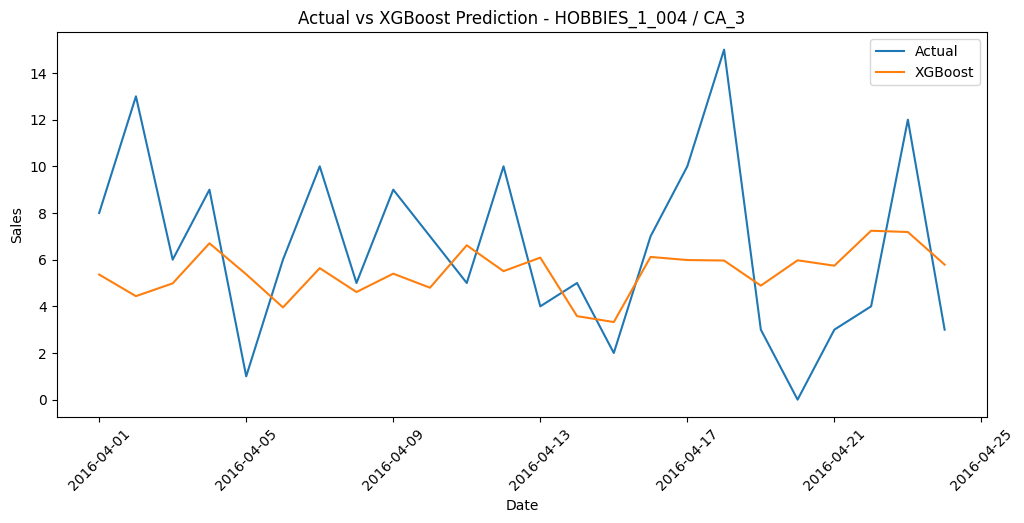

In [ ]:
import matplotlib.pyplot as plt

pair = test_results[
    (test_results["item_id"] == "HOBBIES_1_004") &
    (test_results["store_id"] == "CA_3")
]

plt.figure(figsize=(12, 5))

plt.plot(
    pair["date"],
    pair["sales"],
    label="Actual"
)

plt.plot(
    pair["date"],
    pair["prediction"],
    label="XGBoost"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs XGBoost Prediction - HOBBIES_1_004 / CA_3")
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [ ]:
result_multi["trend"] = (
    result_multi["rolling_mean_7"]
    - result_multi["rolling_mean_28"]
)

In [ ]:
print(result_multi[[
    "date",
    "sales",
    "rolling_mean_7",
    "rolling_mean_28",
    "trend"
]].head(35))

         date  sales  rolling_mean_7  rolling_mean_28  trend
0  2011-01-29      0             NaN              NaN    NaN
1  2011-01-30      0             0.0              0.0    0.0
2  2011-01-31      0             0.0              0.0    0.0
3  2011-02-01      0             0.0              0.0    0.0
4  2011-02-02      0             0.0              0.0    0.0
5  2011-02-03      0             0.0              0.0    0.0
6  2011-02-04      0             0.0              0.0    0.0
7  2011-02-05      0             0.0              0.0    0.0
8  2011-02-06      0             0.0              0.0    0.0
9  2011-02-07      0             0.0              0.0    0.0
10 2011-02-08      0             0.0              0.0    0.0
11 2011-02-09      0             0.0              0.0    0.0
12 2011-02-10      0             0.0              0.0    0.0
13 2011-02-11      0             0.0              0.0    0.0
14 2011-02-12      0             0.0              0.0    0.0
15 2011-02-13      0    

In [ ]:
print(
    result_multi[
        result_multi["sales"] > 0
    ][[
        "date",
        "sales",
        "rolling_mean_7",
        "rolling_mean_28",
        "trend"
    ]].head(20)
)

          date  sales  rolling_mean_7  rolling_mean_28     trend
901 2013-07-18      1        0.000000         0.000000  0.000000
916 2013-08-02      2        0.000000         0.035714 -0.035714
918 2013-08-04      1        0.285714         0.107143  0.178571
919 2013-08-05      1        0.428571         0.142857  0.285714
925 2013-08-11      1        0.285714         0.178571  0.107143
926 2013-08-12      2        0.285714         0.214286  0.071429
927 2013-08-13      1        0.428571         0.285714  0.142857
929 2013-08-15      1        0.571429         0.321429  0.250000
930 2013-08-16      1        0.714286         0.321429  0.392857
934 2013-08-20      1        0.428571         0.357143  0.071429
942 2013-08-28      1        0.000000         0.392857 -0.392857
944 2013-08-30      1        0.142857         0.428571 -0.285714
947 2013-09-02      2        0.285714         0.357143 -0.071429
948 2013-09-03      1        0.571429         0.392857  0.178571
952 2013-09-07      2    

In [ ]:
train_multi["trend"] = (
    train_multi["rolling_mean_7"]
    - train_multi["rolling_mean_28"]
)

test_multi["trend"] = (
    test_multi["rolling_mean_7"]
    - test_multi["rolling_mean_28"]
)

In [ ]:
features_v5 = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "trend"
]

X_train_v5 = train_multi[features_v5]
y_train_v5 = train_multi["sales"]

X_test_v5 = test_multi[features_v5]
y_test_v5 = test_multi["sales"]

In [ ]:
xgb_v5 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_v5.fit(X_train_v5, y_train_v5)

pred_v5 = xgb_v5.predict(X_test_v5)

mae_v5 = mean_absolute_error(y_test_v5, pred_v5)
rmse_v5 = np.sqrt(mean_squared_error(y_test_v5, pred_v5))

print("XGBoost V5 + Trend")
print("MAE :", mae_v5)
print("RMSE:", rmse_v5)

XGBoost V5 + Trend
MAE : 1.020556926727295
RMSE: 1.5548805615346883


In [ ]:
importance_v5 = pd.DataFrame({
    "feature": features_v5,
    "importance": xgb_v5.feature_importances_
})

importance_v5 = importance_v5.sort_values(
    "importance",
    ascending=False
)

print(importance_v5)

           feature  importance
5  rolling_mean_28    0.440735
4   rolling_mean_7    0.254581
2           lag_14    0.070872
6            trend    0.067197
0            lag_1    0.061560
3           lag_28    0.055548
1            lag_7    0.049508


In [ ]:
import joblib

joblib.dump(
    xgb_v5,
    "../models/xgboost_best.pkl"
)

print("XGBoost V5 saved as best model.")

XGBoost V5 saved as best model.


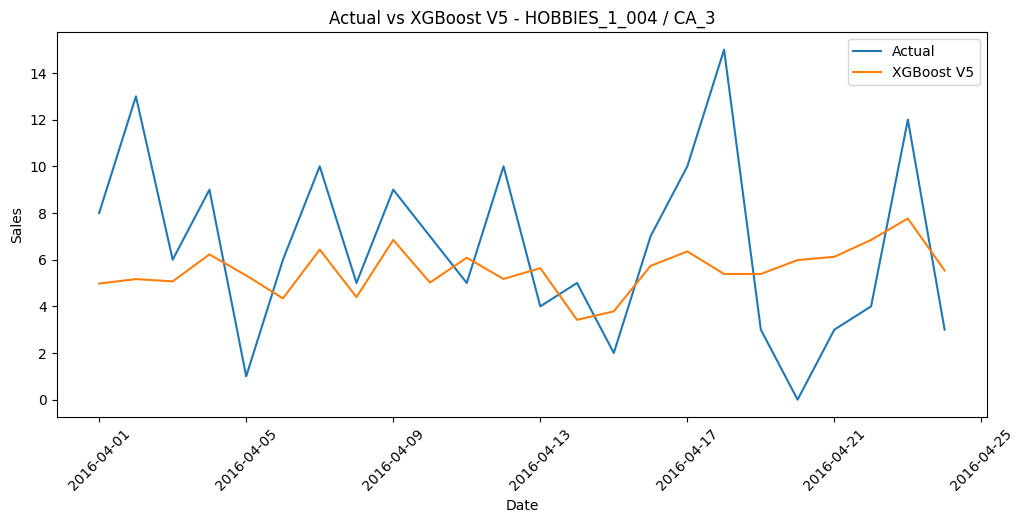

In [ ]:
import matplotlib.pyplot as plt

pair_v5 = test_multi[
    (test_multi["item_id"] == "HOBBIES_1_004") &
    (test_multi["store_id"] == "CA_3")
].copy()

pair_v5["prediction"] = xgb_v5.predict(
    pair_v5[features_v5]
)

plt.figure(figsize=(12, 5))

plt.plot(
    pair_v5["date"],
    pair_v5["sales"],
    label="Actual"
)

plt.plot(
    pair_v5["date"],
    pair_v5["prediction"],
    label="XGBoost V5"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs XGBoost V5 - HOBBIES_1_004 / CA_3")
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Calendar features

train_multi["dayofweek"] = train_multi["date"].dt.dayofweek
test_multi["dayofweek"] = test_multi["date"].dt.dayofweek

train_multi["month"] = train_multi["date"].dt.month
test_multi["month"] = test_multi["date"].dt.month

train_multi["weekofyear"] = train_multi["date"].dt.isocalendar().week.astype(int)
test_multi["weekofyear"] = test_multi["date"].dt.isocalendar().week.astype(int)

# Weekend indicator
train_multi["is_weekend"] = (
    train_multi["dayofweek"] >= 5
).astype(int)

test_multi["is_weekend"] = (
    test_multi["dayofweek"] >= 5
).astype(int)

print(
    train_multi[
        ["date", "dayofweek", "month", "weekofyear", "is_weekend"]
    ].head(10)
)

         date  dayofweek  month  weekofyear  is_weekend
28 2011-02-26          5      2           8           1
29 2011-02-27          6      2           8           1
30 2011-02-28          0      2           9           0
31 2011-03-01          1      3           9           0
32 2011-03-02          2      3           9           0
33 2011-03-03          3      3           9           0
34 2011-03-04          4      3           9           0
35 2011-03-05          5      3           9           1
36 2011-03-06          6      3           9           1
37 2011-03-07          0      3          10           0


In [ ]:
# Load calendar data
calendar = pd.read_csv("../data/raw/calendar.csv")

calendar["date"] = pd.to_datetime(calendar["date"])

# Keep the useful event columns
calendar_events = calendar[
    [
        "date",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
        "snap_CA",
        "snap_TX",
        "snap_WI"
    ]
].copy()

# Create a simple event indicator
calendar_events["has_event"] = (
    calendar_events["event_name_1"].notna() |
    calendar_events["event_name_2"].notna()
).astype(int)

print(calendar_events.head(10))

        date event_name_1 event_type_1 event_name_2 event_type_2  snap_CA  \
0 2011-01-29          NaN          NaN          NaN          NaN        0   
1 2011-01-30          NaN          NaN          NaN          NaN        0   
2 2011-01-31          NaN          NaN          NaN          NaN        0   
3 2011-02-01          NaN          NaN          NaN          NaN        1   
4 2011-02-02          NaN          NaN          NaN          NaN        1   
5 2011-02-03          NaN          NaN          NaN          NaN        1   
6 2011-02-04          NaN          NaN          NaN          NaN        1   
7 2011-02-05          NaN          NaN          NaN          NaN        1   
8 2011-02-06    SuperBowl     Sporting          NaN          NaN        1   
9 2011-02-07          NaN          NaN          NaN          NaN        1   

   snap_TX  snap_WI  has_event  
0        0        0          0  
1        0        0          0  
2        0        0          0  
3        1        0 

In [ ]:
# Merge event features into train and test

train_multi = train_multi.merge(
    calendar_events,
    on="date",
    how="left"
)

test_multi = test_multi.merge(
    calendar_events,
    on="date",
    how="left"
)

print(
    train_multi[
        [
            "date",
            "dayofweek",
            "month",
            "weekofyear",
            "is_weekend",
            "event_name_1",
            "event_type_1",
            "event_name_2",
            "event_type_2",
            "has_event",
            "snap_CA",
            "snap_TX",
            "snap_WI"
        ]
    ].head(15)
)

         date  dayofweek  month  weekofyear  is_weekend event_name_1  \
0  2011-02-26          5      2           8           1          NaN   
1  2011-02-27          6      2           8           1          NaN   
2  2011-02-28          0      2           9           0          NaN   
3  2011-03-01          1      3           9           0          NaN   
4  2011-03-02          2      3           9           0          NaN   
5  2011-03-03          3      3           9           0          NaN   
6  2011-03-04          4      3           9           0          NaN   
7  2011-03-05          5      3           9           1          NaN   
8  2011-03-06          6      3           9           1          NaN   
9  2011-03-07          0      3          10           0          NaN   
10 2011-03-08          1      3          10           0          NaN   
11 2011-03-09          2      3          10           0    LentStart   
12 2011-03-10          3      3          10           0         

In [ ]:
features_v6 = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "trend",
    "dayofweek",
    "month",
    "weekofyear",
    "is_weekend",
    "has_event"
]

X_train_v6 = train_multi[features_v6]
y_train_v6 = train_multi["sales"]

X_test_v6 = test_multi[features_v6]
y_test_v6 = test_multi["sales"]

print("Features:", features_v6)
print("X_train:", X_train_v6.shape)
print("X_test :", X_test_v6.shape)

Features: ['lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'trend', 'dayofweek', 'month', 'weekofyear', 'is_weekend', 'has_event']
X_train: (27915, 12)
X_test : (360, 12)


In [ ]:
from xgboost import XGBRegressor

xgb_v6 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_v6.fit(
    X_train_v6,
    y_train_v6
)

pred_v6 = xgb_v6.predict(X_test_v6)

mae_v6 = mean_absolute_error(
    y_test_v6,
    pred_v6
)

rmse_v6 = np.sqrt(
    mean_squared_error(
        y_test_v6,
        pred_v6
    )
)

print("XGBoost V6 + Calendar")
print("MAE :", mae_v6)
print("RMSE:", rmse_v6)

XGBoost V6 + Calendar
MAE : 0.9876020550727844
RMSE: 1.498472628216491


| Model                     |        MAE |       RMSE |
| ------------------------- | ---------: | ---------: |
| Naive baseline            |     1.2528 |     2.0783 |
| RF V4                     |     1.0655 |     1.6160 |
| XGBoost V4                |     1.0325 |     1.5906 |
| XGBoost V5 + Trend        |     1.0206 |     1.5549 |
| **XGBoost V6 + Calendar** | **0.9876** | **1.4985** |


In [ ]:
print("Event types:")
print(
    calendar_events["event_type_1"]
    .dropna()
    .value_counts()
)

print("\nSecond event types:")
print(
    calendar_events["event_type_2"]
    .dropna()
    .value_counts()
)

Event types:
event_type_1
Religious    55
National     52
Cultural     37
Sporting     18
Name: count, dtype: int64

Second event types:
event_type_2
Cultural     4
Religious    1
Name: count, dtype: int64


In [ ]:
importance_v6 = pd.DataFrame({
    "feature": features_v6,
    "importance": xgb_v6.feature_importances_
})

importance_v6 = importance_v6.sort_values(
    "importance",
    ascending=False
)

print(importance_v6)

            feature  importance
5   rolling_mean_28    0.462942
10       is_weekend    0.076017
4    rolling_mean_7    0.058784
0             lag_1    0.058215
7         dayofweek    0.056595
2            lag_14    0.055746
3            lag_28    0.042901
9        weekofyear    0.041112
6             trend    0.040508
11        has_event    0.040064
1             lag_7    0.034846
8             month    0.032270


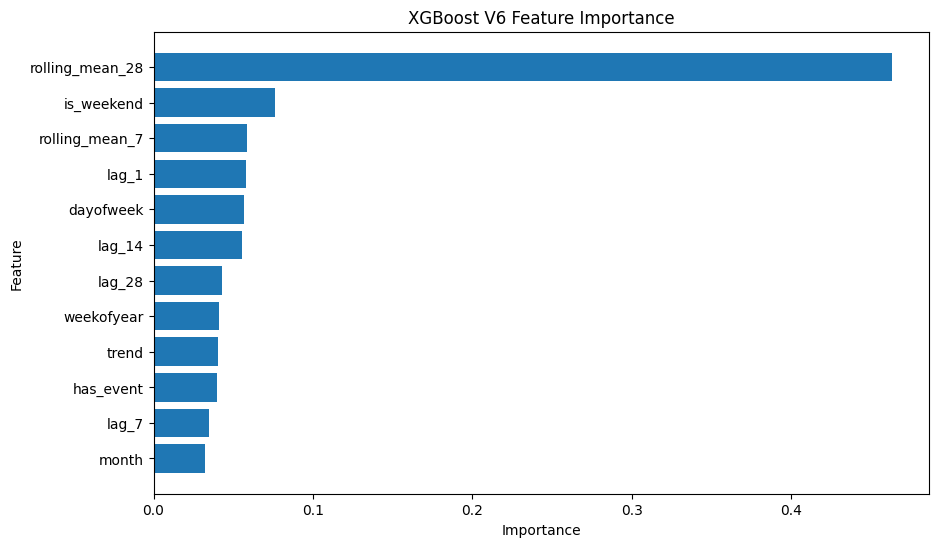

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_v6["feature"],
    importance_v6["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost V6 Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [ ]:
features_v7 = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "trend",
    "dayofweek",
    "is_weekend",
    "has_event"
]

X_train_v7 = train_multi[features_v7]
y_train_v7 = train_multi["sales"]

X_test_v7 = test_multi[features_v7]
y_test_v7 = test_multi["sales"]

In [ ]:
xgb_v7 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_v7.fit(
    X_train_v7,
    y_train_v7
)
pred_v7=xgb_v7.predict(X_test_v7)
mae_v7 = mean_absolute_error(y_test_v7, pred_v7)

rmse_v7 = np.sqrt(
    mean_squared_error(y_test_v7, pred_v7)
)

print("XGBoost V7")
print("MAE :", mae_v7)
print("RMSE:", rmse_v7)

XGBoost V7
MAE : 1.0039252042770386
RMSE: 1.5310533358342515


V6 is better then V7

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    xgb_v6,
    X_test_v6,
    y_test_v6,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": features_v6,
    "importance": perm.importances_mean
}).sort_values(
    "importance",
    ascending=False
)

print(perm_importance)

            feature  importance
5   rolling_mean_28    0.503334
4    rolling_mean_7    0.093385
7         dayofweek    0.054205
0             lag_1    0.049561
2            lag_14    0.017458
6             trend    0.013486
10       is_weekend    0.002016
3            lag_28    0.000917
11        has_event    0.000000
8             month    0.000000
9        weekofyear   -0.004404
1             lag_7   -0.004985


In [ ]:
validation_train = train_multi[
    train_multi["date"] < "2016-03-04"
].copy()

validation_test = train_multi[
    train_multi["date"] >= "2016-03-04"
].copy()

print("Validation train:", validation_train.shape)
print("Validation test :", validation_test.shape)
print(
    "Validation period:",
    validation_test["date"].min(),
    "to",
    validation_test["date"].max()
)

Validation train: (27495, 23)
Validation test : (420, 23)
Validation period: 2016-03-04 00:00:00 to 2016-03-31 00:00:00


In [ ]:
X_train_val = validation_train[features_v6]
y_train_val = validation_train["sales"]

X_test_val = validation_test[features_v6]
y_test_val = validation_test["sales"]

print("X_train:", X_train_val.shape)
print("X_test :", X_test_val.shape)

X_train: (27495, 12)
X_test : (420, 12)


In [ ]:
xgb_val = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_val.fit(
    X_train_val,
    y_train_val
)

pred_val = xgb_val.predict(X_test_val)

mae_val = mean_absolute_error(
    y_test_val,
    pred_val
)

rmse_val = np.sqrt(
    mean_squared_error(
        y_test_val,
        pred_val
    )
)

print("Validation MAE :", mae_val)
print("Validation RMSE:", rmse_val)

Validation MAE : 1.009135127067566
Validation RMSE: 1.6053616007669171


The V6 model maintains similar MAE performance across two consecutive time periods, although RMSE varies because some periods contain larger prediction errors.

In [ ]:
baseline_val = X_test_val["lag_1"]

baseline_mae_val = mean_absolute_error(
    y_test_val,
    baseline_val
)

baseline_rmse_val = np.sqrt(
    mean_squared_error(
        y_test_val,
        baseline_val
    )
)

print("Naive Baseline MAE :", baseline_mae_val)
print("Naive Baseline RMSE:", baseline_rmse_val)

Naive Baseline MAE : 1.2333333333333334
Naive Baseline RMSE: 2.096482314554095


What we've established

Your current model:

Historical demand
       ↓
Lag features
       ↓
Rolling averages
       ↓
Trend
       ↓
Calendar information
       ↓
XGBoost
       ↓
Demand prediction

In [ ]:
validation_results = pd.DataFrame({
    "experiment": [
        "March Naive Baseline",
        "March XGBoost V6"
    ],
    "MAE": [
        baseline_mae_val,
        mae_val
    ],
    "RMSE": [
        baseline_rmse_val,
        rmse_val
    ]
})

validation_results.to_csv(
    "../models/validation_results.csv",
    index=False
)

print(validation_results)

             experiment       MAE      RMSE
0  March Naive Baseline  1.233333  2.096482
1      March XGBoost V6  1.009135  1.605362


V6 is currently our validated model, with:

-> April MAE: 0.9876
-> April RMSE: 1.4985
-> March MAE: 1.0091
-> March RMSE: 1.6054
-> It beats the naive baseline on both periods

In [ ]:
test_results_v6 = test_multi.copy()

test_results_v6["prediction"] = pred_v6

pair_metrics_v6 = (
    test_results_v6
    .groupby(["item_id", "store_id"])
    .apply(
        lambda df: pd.Series({
            "MAE": mean_absolute_error(
                df["sales"],
                df["prediction"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    df["sales"],
                    df["prediction"]
                )
            )
        }),
        include_groups=False
    )
    .reset_index()
)

print(
    pair_metrics_v6
    .sort_values("RMSE", ascending=False)
)

          item_id store_id       MAE      RMSE
11  HOBBIES_1_004     CA_3  2.781289  3.484222
10  HOBBIES_1_004     CA_2  1.678981  2.253517
14  HOBBIES_1_005     CA_3  1.815594  2.067611
9   HOBBIES_1_004     CA_1  1.491351  1.705850
13  HOBBIES_1_005     CA_2  1.091838  1.372326
0   HOBBIES_1_001     CA_1  0.871641  1.205478
2   HOBBIES_1_001     CA_3  0.967482  1.166406
7   HOBBIES_1_003     CA_2  0.826897  1.086073
1   HOBBIES_1_001     CA_2  0.866854  1.068667
12  HOBBIES_1_005     CA_1  0.842244  1.025723
6   HOBBIES_1_003     CA_1  0.542813  0.720875
4   HOBBIES_1_002     CA_2  0.217272  0.455481
5   HOBBIES_1_002     CA_3  0.173828  0.451922
8   HOBBIES_1_003     CA_3  0.403543  0.445531
3   HOBBIES_1_002     CA_1  0.242403  0.278767


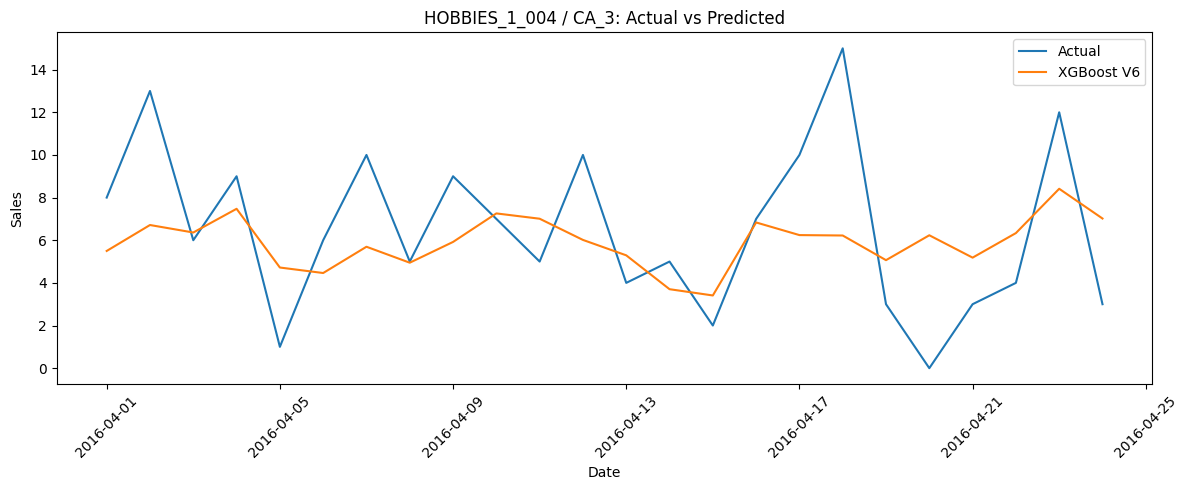

In [ ]:
pair = test_results_v6[
    (test_results_v6["item_id"] == "HOBBIES_1_004") &
    (test_results_v6["store_id"] == "CA_3")
]

plt.figure(figsize=(12, 5))

plt.plot(
    pair["date"],
    pair["sales"],
    label="Actual"
)

plt.plot(
    pair["date"],
    pair["prediction"],
    label="XGBoost V6"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("HOBBIES_1_004 / CA_3: Actual vs Predicted")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
prices = pd.read_csv("../data/raw/sell_prices.csv")

pair_price = prices[
    (prices["item_id"] == "HOBBIES_1_004") &
    (prices["store_id"] == "CA_3")
].copy()

print(pair_price)

        store_id        item_id  wm_yr_wk  sell_price
1336314     CA_3  HOBBIES_1_004     11102        4.34
1336315     CA_3  HOBBIES_1_004     11103        4.34
1336316     CA_3  HOBBIES_1_004     11104        4.34
1336317     CA_3  HOBBIES_1_004     11105        4.34
1336318     CA_3  HOBBIES_1_004     11106        4.34
...          ...            ...       ...         ...
1336590     CA_3  HOBBIES_1_004     11617        4.64
1336591     CA_3  HOBBIES_1_004     11618        4.64
1336592     CA_3  HOBBIES_1_004     11619        4.64
1336593     CA_3  HOBBIES_1_004     11620        4.64
1336594     CA_3  HOBBIES_1_004     11621        4.64

[281 rows x 4 columns]


In [ ]:
calendar = pd.read_csv("../data/raw/calendar.csv")
calendar["date"] = pd.to_datetime(calendar["date"])

pair_price = test_multi[
    (test_multi["item_id"] == "HOBBIES_1_004") &
    (test_multi["store_id"] == "CA_3")
][[
    "date",
    "sales"
]].copy()

# Add wm_yr_wk using the small calendar file
pair_price = pair_price.merge(
    calendar[["date", "wm_yr_wk"]],
    on="date",
    how="left"
)

# Add price
price_lookup = prices[
    (prices["item_id"] == "HOBBIES_1_004") &
    (prices["store_id"] == "CA_3")
][[
    "wm_yr_wk",
    "sell_price"
]]

pair_price = pair_price.merge(
    price_lookup,
    on="wm_yr_wk",
    how="left"
)

print(
    pair_price[
        ["date", "sales", "sell_price"]
    ].to_string(index=False)
)

      date  sales  sell_price
2016-04-01      8        4.64
2016-04-02     13        4.64
2016-04-03      6        4.64
2016-04-04      9        4.64
2016-04-05      1        4.64
2016-04-06      6        4.64
2016-04-07     10        4.64
2016-04-08      5        4.64
2016-04-09      9        4.64
2016-04-10      7        4.64
2016-04-11      5        4.64
2016-04-12     10        4.64
2016-04-13      4        4.64
2016-04-14      5        4.64
2016-04-15      2        4.64
2016-04-16      7        4.64
2016-04-17     10        4.64
2016-04-18     15        4.64
2016-04-19      3        4.64
2016-04-20      0        4.64
2016-04-21      3        4.64
2016-04-22      4        4.64
2016-04-23     12        4.64
2016-04-24      3        4.64


In [ ]:
pair_calendar = test_multi[
    (test_multi["item_id"] == "HOBBIES_1_004") &
    (test_multi["store_id"] == "CA_3")
][[
    "date",
    "sales",
    "dayofweek",
    "is_weekend",
    "has_event",
    "snap_CA"
]].copy()

print(pair_calendar.to_string(index=False))

      date  sales  dayofweek  is_weekend  has_event  snap_CA
2016-04-01      8          4           0          0        1
2016-04-02     13          5           1          0        1
2016-04-03      6          6           1          0        1
2016-04-04      9          0           0          0        1
2016-04-05      1          1           0          0        1
2016-04-06      6          2           0          0        1
2016-04-07     10          3           0          0        1
2016-04-08      5          4           0          0        1
2016-04-09      9          5           1          0        1
2016-04-10      7          6           1          0        1
2016-04-11      5          0           0          0        0
2016-04-12     10          1           0          0        0
2016-04-13      4          2           0          0        0
2016-04-14      5          3           0          0        0
2016-04-15      2          4           0          0        0
2016-04-16      7       

In [ ]:
pair = test_results_v6[
    (test_results_v6["item_id"] == "HOBBIES_1_004") &
    (test_results_v6["store_id"] == "CA_3")
].copy()

pair["error"] = pair["sales"] - pair["prediction"]

print(
    pair[[
        "date",
        "sales",
        "prediction",
        "error"
    ]].sort_values(
        "sales",
        ascending=False
    ).head(10)
)

          date  sales  prediction     error
281 2016-04-18     15    6.221990  8.778010
265 2016-04-02     13    6.713563  6.286437
286 2016-04-23     12    8.413672  3.586328
270 2016-04-07     10    5.694473  4.305527
280 2016-04-17     10    6.241250  3.758750
275 2016-04-12     10    6.014825  3.985175
267 2016-04-04      9    7.474049  1.525951
272 2016-04-09      9    5.920178  3.079822
264 2016-04-01      8    5.497517  2.502483
273 2016-04-10      7    7.257932 -0.257932


In [ ]:
print(result_multi.columns.tolist())

['item_id', 'store_id', 'date', 'sales', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'trend']


In [ ]:
result_multi["date"] = pd.to_datetime(result_multi["date"])

result_multi = result_multi.sort_values(
    ["item_id", "store_id", "date"]
).copy()

result_multi["dayofweek"] = result_multi["date"].dt.dayofweek

In [ ]:
result_multi["same_weekday_mean"] = (
    result_multi
    .groupby(["item_id", "store_id", "dayofweek"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
)

In [ ]:
print(
    result_multi[
        (result_multi["item_id"] == "HOBBIES_1_004") &
        (result_multi["store_id"] == "CA_3")
    ][[
        "date",
        "sales",
        "dayofweek",
        "same_weekday_mean"
    ]].tail(30)
)

            date  sales  dayofweek  same_weekday_mean
22926 2016-03-26      9          5               5.75
22927 2016-03-27      3          6               7.00
22928 2016-03-28      6          0               6.00
22929 2016-03-29     10          1               7.75
22930 2016-03-30      4          2               4.50
22931 2016-03-31      3          3               6.00
22932 2016-04-01      8          4               2.50
22933 2016-04-02     13          5               7.50
22934 2016-04-03      6          6               6.25
22935 2016-04-04      9          0               5.75
22936 2016-04-05      1          1               7.75
22937 2016-04-06      6          2               4.50
22938 2016-04-07     10          3               4.75
22939 2016-04-08      5          4               3.50
22940 2016-04-09      9          5               8.25
22941 2016-04-10      7          6               5.00
22942 2016-04-11      5          0               7.00
22943 2016-04-12     10     

In [ ]:
print([
    col for col in result_multi.columns
    if "event" in col.lower()
])

[]


In [ ]:
print(result_multi.columns.tolist())

['item_id', 'store_id', 'date', 'sales', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'trend', 'dayofweek', 'same_weekday_mean']


In [ ]:
calendar = pd.read_csv("../data/raw/calendar.csv")
calendar["date"] = pd.to_datetime(calendar["date"])

calendar_events = calendar[
    ["date", "event_name_1", "event_name_2"]
].copy()

calendar_events["has_event"] = (
    calendar_events["event_name_1"].notna() |
    calendar_events["event_name_2"].notna()
).astype(int)

result_multi = result_multi.merge(
    calendar_events[["date", "has_event"]],
    on="date",
    how="left"
)

In [ ]:
print(result_multi.columns.tolist())

['item_id', 'store_id', 'date', 'sales', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'trend', 'dayofweek', 'same_weekday_mean', 'has_event']


In [ ]:
print(result_multi[features_v7].isna().sum())

KeyError: "['is_weekend'] not in index"

In [ ]:
result_v7 = result_multi.dropna(subset=features_v7).copy()

print("Original shape:", result_multi.shape)
print("After removing NaNs:", result_v7.shape)

Original shape: (28695, 17)
After removing NaNs: (28275, 17)


In [ ]:
result_v7 = result_multi.dropna(subset=features_v7).copy()

print("Original shape:", result_multi.shape)
print("After removing NaNs:", result_v7.shape)

Original shape: (28695, 17)
After removing NaNs: (28275, 17)


In [ ]:
train_v7 = result_v7[result_v7["date"] < "2016-04-01"].copy()
test_v7 = result_v7[
    (result_v7["date"] >= "2016-04-01") &
    (result_v7["date"] <= "2016-04-24")
].copy()

print("Train:", train_v7.shape)
print("Test:", test_v7.shape)

Train: (27915, 17)
Test: (360, 17)


In [ ]:
X_train_v7 = train_v7[features_v7]
y_train_v7 = train_v7["sales"]

X_test_v7 = test_v7[features_v7]
y_test_v7 = test_v7["sales"]

In [ ]:
from xgboost import XGBRegressor

xgb_v7 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_v7.fit(X_train_v7, y_train_v7)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred_v7 = xgb_v7.predict(X_test_v7)

mae_v7 = mean_absolute_error(y_test_v7, pred_v7)
rmse_v7 = np.sqrt(mean_squared_error(y_test_v7, pred_v7))

print("V7 MAE:", mae_v7)
print("V7 RMSE:", rmse_v7)

V7 MAE: 1.0039252042770386
V7 RMSE: 1.5310533358342515


In [ ]:
result_multi["rolling_max_7"] = (
    result_multi
    .groupby(["item_id", "store_id"])["sales"]
    .transform(lambda x: x.shift(1).rolling(7).max())
)

In [ ]:
features_v8 = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "trend",
    "dayofweek",
    "month",
    "weekofyear",
    "is_weekend",
    "has_event",
    "rolling_max_7"
]

In [ ]:
result_multi["month"] = result_multi["date"].dt.month
result_multi["weekofyear"] = result_multi["date"].dt.isocalendar().week.astype(int)
result_multi["is_weekend"] = (result_multi["dayofweek"] >= 5).astype(int)

In [ ]:
print(result_multi[features_v8].isna().sum())

lag_1               15
lag_7              105
lag_14             210
lag_28             420
rolling_mean_7      15
rolling_mean_28     15
trend               15
dayofweek            0
month                0
weekofyear           0
is_weekend           0
has_event            0
rolling_max_7      105
dtype: int64


In [ ]:
result_v8 = result_multi.dropna(subset=features_v8).copy()

print("Original shape:", result_multi.shape)
print("V8 shape:", result_v8.shape)

Original shape: (28695, 18)
V8 shape: (28275, 18)


In [ ]:
print(result_v8[features_v8].isna().sum())

lag_1              0
lag_7              0
lag_14             0
lag_28             0
rolling_mean_7     0
rolling_mean_28    0
trend              0
dayofweek          0
month              0
weekofyear         0
is_weekend         0
has_event          0
rolling_max_7      0
dtype: int64


In [ ]:
train_v8 = result_v8[result_v8["date"] < "2016-04-01"].copy()

test_v8 = result_v8[
    (result_v8["date"] >= "2016-04-01") &
    (result_v8["date"] <= "2016-04-24")
].copy()

print("Train:", train_v8.shape)
print("Test:", test_v8.shape)

Train: (27915, 18)
Test: (360, 18)


In [ ]:
X_train_v8 = train_v8[features_v8]
y_train_v8 = train_v8["sales"]

X_test_v8 = test_v8[features_v8]
y_test_v8 = test_v8["sales"]

In [ ]:
from xgboost import XGBRegressor

xgb_v8 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_v8.fit(X_train_v8, y_train_v8)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred_v8 = xgb_v8.predict(X_test_v8)

mae_v8 = mean_absolute_error(y_test_v8, pred_v8)
rmse_v8 = np.sqrt(mean_squared_error(y_test_v8, pred_v8))

print("V8 MAE:", mae_v8)
print("V8 RMSE:", rmse_v8)

V8 MAE: 0.9763123989105225
V8 RMSE: 1.4801849656896966


| Model                  |        MAE |       RMSE |
| ---------------------- | ---------: | ---------: |
| V6                     |     0.9876 |     1.4985 |
| V7 + same-weekday      |     1.0029 |     1.5169 |
| **V8 + rolling_max_7** | **0.9763** | **1.4802** |


In [ ]:
validation_train_v8 = result_v8[
    result_v8["date"] < "2016-03-04"
].copy()

validation_test_v8 = result_v8[
    (result_v8["date"] >= "2016-03-04") &
    (result_v8["date"] <= "2016-03-31")
].copy()

print("Validation train:", validation_train_v8.shape)
print("Validation test:", validation_test_v8.shape)

Validation train: (27495, 18)
Validation test: (420, 18)


In [ ]:
X_train_val_v8 = validation_train_v8[features_v8]
y_train_val_v8 = validation_train_v8["sales"]

X_test_val_v8 = validation_test_v8[features_v8]
y_test_val_v8 = validation_test_v8["sales"]

In [ ]:
xgb_val_v8 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_val_v8.fit(X_train_val_v8, y_train_val_v8)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [ ]:
pred_val_v8 = xgb_val_v8.predict(X_test_val_v8)

mae_val_v8 = mean_absolute_error(y_test_val_v8, pred_val_v8)
rmse_val_v8 = np.sqrt(
    mean_squared_error(y_test_val_v8, pred_val_v8)
)

print("V8 March MAE:", mae_val_v8)
print("V8 March RMSE:", rmse_val_v8)

V8 March MAE: 1.0078870058059692
V8 March RMSE: 1.6137373235723205


| Model      |        March MAE |      March RMSE |
| ---------- | ---------------: | --------------: |
| V6         |           1.0091 |      **1.6054** |
| V8         |       **1.0079** |          1.6137 |
| Difference | **0.13% better** | **0.52% worse** |


In [ ]:
test_results_v8 = test_v8.copy()
test_results_v8["prediction"] = pred_v8
test_results_v8["error"] = (
    test_results_v8["sales"] - test_results_v8["prediction"]
)

print(
    test_results_v8[
        ["date", "item_id", "store_id", "sales", "prediction", "error"]
    ]
    .sort_values("sales", ascending=False)
    .head(15)
)

            date        item_id store_id  sales  prediction     error
22949 2016-04-18  HOBBIES_1_004     CA_3     15    6.210078  8.789922
22933 2016-04-02  HOBBIES_1_004     CA_3     13    6.815355  6.184645
22954 2016-04-23  HOBBIES_1_004     CA_3     12    7.921035  4.078965
22948 2016-04-17  HOBBIES_1_004     CA_3     10    6.470747  3.529253
22938 2016-04-07  HOBBIES_1_004     CA_3     10    6.245684  3.754316
22943 2016-04-12  HOBBIES_1_004     CA_3     10    5.500257  4.499743
21026 2016-04-08  HOBBIES_1_004     CA_2     10    3.129311  6.870689
22940 2016-04-09  HOBBIES_1_004     CA_3      9    5.869264  3.130736
22935 2016-04-04  HOBBIES_1_004     CA_3      9    7.042965  1.957035
22932 2016-04-01  HOBBIES_1_004     CA_3      8    5.387969  2.612031
22947 2016-04-16  HOBBIES_1_004     CA_3      7    6.375556  0.624444
22941 2016-04-10  HOBBIES_1_004     CA_3      7    7.018322 -0.018322
19128 2016-04-23  HOBBIES_1_004     CA_1      7    3.615619  3.384381
22937 2016-04-06  HO

In [ ]:
importance = pd.Series(
    xgb_val_v8.feature_importances_,
    index=features_v8
).sort_values(ascending=False)

print(importance)

rolling_mean_28    0.415247
rolling_max_7      0.123318
is_weekend         0.102426
dayofweek          0.048278
rolling_mean_7     0.040082
lag_1              0.039879
lag_14             0.038607
weekofyear         0.035857
lag_28             0.035138
trend              0.034006
has_event          0.030602
month              0.029145
lag_7              0.027417
dtype: float32


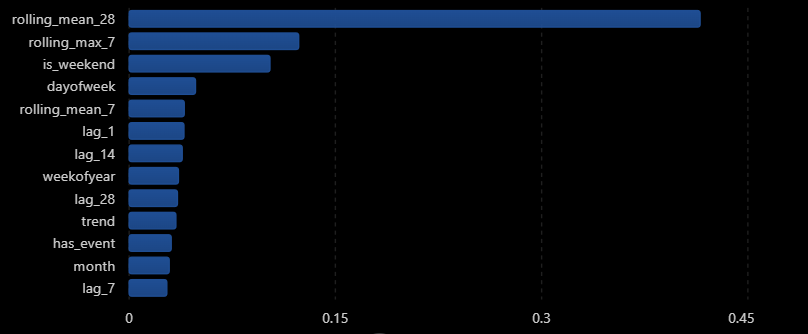

In [ ]:
perm_v8 = permutation_importance(
    xgb_val_v8,
    X_test_val_v8,
    y_test_val_v8,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance_v8 = pd.Series(
    perm_v8.importances_mean,
    index=features_v8
).sort_values(ascending=False)

print(perm_importance_v8)

rolling_mean_28    0.496600
rolling_mean_7     0.084256
rolling_max_7      0.052116
lag_1              0.047370
lag_14             0.044047
lag_28             0.035928
dayofweek          0.020401
trend              0.019715
lag_7              0.008806
is_weekend         0.001859
weekofyear         0.001158
has_event          0.000572
month              0.000000
dtype: float64


In [ ]:
features_v9 = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_max_7",
    "rolling_max_28",
    "rolling_std_7",
    "trend",
    "dayofweek",
    "month",
    "weekofyear",
    "is_weekend",
    "has_event"
]

In [ ]:
result_multi["rolling_max_28"] = (
    result_multi
    .groupby(["item_id", "store_id"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(28).max()
    )
)

result_multi["rolling_std_7"] = (
    result_multi
    .groupby(["item_id", "store_id"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).std()
    )
)

In [ ]:
print(result_multi[features_v9].isna().sum())

lag_1               15
lag_7              105
lag_14             210
lag_28             420
rolling_mean_7      15
rolling_mean_28     15
rolling_max_7      105
rolling_max_28     420
rolling_std_7      105
trend               15
dayofweek            0
month                0
weekofyear           0
is_weekend           0
has_event            0
dtype: int64


In [ ]:
result_v9 = result_multi.dropna(
    subset=features_v9
).copy()

print(result_v9.shape)

(28275, 20)


In [ ]:
train_v9 = result_v9[
    result_v9["date"] < "2016-04-01"
].copy()

test_v9 = result_v9[
    result_v9["date"] >= "2016-04-01"
].copy()

print(train_v9.shape)
print(test_v9.shape)

(27915, 20)
(360, 20)


In [ ]:
from xgboost import XGBRegressor

X_train_v9 = train_v9[features_v9]
y_train_v9 = train_v9["sales"]

X_test_v9 = test_v9[features_v9]
y_test_v9 = test_v9["sales"]

xgb_v9 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_v9.fit(X_train_v9, y_train_v9)

pred_v9 = xgb_v9.predict(X_test_v9)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_v9 = mean_absolute_error(y_test_v9, pred_v9)
rmse_v9 = np.sqrt(mean_squared_error(y_test_v9, pred_v9))

print("V9 MAE:", mae_v9)
print("V9 RMSE:", rmse_v9)

V9 MAE: 0.9956482648849487
V9 RMSE: 1.510043692304046


In [ ]:
validation_train_v9 = result_v9[
    result_v9["date"] < "2016-03-04"
].copy()

validation_test_v9 = result_v9[
    result_v9["date"] >= "2016-03-04"
].copy()

print(validation_train_v9.shape)
print(validation_test_v9.shape)

(27495, 20)
(780, 20)


In [ ]:
X_train_val_v9 = validation_train_v9[features_v9]
y_train_val_v9 = validation_train_v9["sales"]

X_test_val_v9 = validation_test_v9[features_v9]
y_test_val_v9 = validation_test_v9["sales"]

xgb_val_v9 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_val_v9.fit(X_train_val_v9, y_train_val_v9)

pred_val_v9 = xgb_val_v9.predict(X_test_val_v9)

In [ ]:
mae_val_v9 = mean_absolute_error(
    y_test_val_v9,
    pred_val_v9
)

rmse_val_v9 = np.sqrt(
    mean_squared_error(
        y_test_val_v9,
        pred_val_v9
    )
)

print("V9 March MAE:", mae_val_v9)
print("V9 March RMSE:", rmse_val_v9)

V9 March MAE: 1.0122051239013672
V9 March RMSE: 1.5755636750588784


In [ ]:
print(result_multi[["item_id", "store_id"]].drop_duplicates().sort_values(
    ["item_id", "store_id"]
))

             item_id store_id
0      HOBBIES_1_001     CA_1
1913   HOBBIES_1_001     CA_2
3826   HOBBIES_1_001     CA_3
5739   HOBBIES_1_002     CA_1
7652   HOBBIES_1_002     CA_2
9565   HOBBIES_1_002     CA_3
11478  HOBBIES_1_003     CA_1
13391  HOBBIES_1_003     CA_2
15304  HOBBIES_1_003     CA_3
17217  HOBBIES_1_004     CA_1
19130  HOBBIES_1_004     CA_2
21043  HOBBIES_1_004     CA_3
22956  HOBBIES_1_005     CA_1
24869  HOBBIES_1_005     CA_2
26782  HOBBIES_1_005     CA_3


In [ ]:
print(result_multi.columns.tolist())

['item_id', 'store_id', 'date', 'sales', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'trend', 'dayofweek', 'same_weekday_mean', 'has_event', 'rolling_max_7', 'month', 'weekofyear', 'is_weekend', 'rolling_max_28', 'rolling_std_7']


In [ ]:
import os

print(os.getcwd())

d:\My_project\Demand forecasting\notebooks


In [ ]:
print(os.listdir())

['.tmp', 'data_understanding.ipynb', 'date_transformation.ipynb', 'feature_engineering copy.ipynb', 'feature_engineering.ipynb']


In [ ]:
import os

print(os.path.exists("../data/processed"))
print(os.listdir("../data/processed"))

True
['calendar.csv', 'sales_processed.parquet', 'sales_train_validation.csv', 'sell_prices.csv']


In [ ]:
import duckdb

con = duckdb.connect()

query = """
SELECT
    item_id,
    dept_id,
    cat_id,
    store_id,
    state_id,
    date,
    sales,
    dayofweek,
    month,
    weekofyear,
    is_weekend,
    has_event
FROM read_parquet('../data/processed/sales_processed.parquet')
WHERE item_id IN (
    'HOBBIES_1_001',
    'HOBBIES_1_002',
    'HOBBIES_1_003',
    'HOBBIES_1_004',
    'HOBBIES_1_005'
)
AND state_id IN ('CA', 'TX', 'WI')
"""

result_v10_base = con.execute(query).df()

print(result_v10_base.shape)
print(result_v10_base[['item_id', 'store_id', 'state_id']].drop_duplicates().shape)

BinderException: Binder Error: Referenced column "weekofyear" not found in FROM clause!
Candidate bindings: "week", "weekday", "dayofweek", "event_type_1", "event_type_2"

LINE 12:     weekofyear,
             ^

In [ ]:
result_multi["weekofyear"] = result_multi["date"].dt.isocalendar().week.astype(int)

In [ ]:
import duckdb

con = duckdb.connect()

query = """
SELECT
    item_id,
    dept_id,
    cat_id,
    store_id,
    state_id,
    date,
    sales,
    dayofweek,
    month,
    week,
    event_name_1,
    event_type_1,
    event_name_2,
    event_type_2,
    snap_CA,
    snap_TX,
    snap_WI
FROM read_parquet('../data/processed/sales_processed.parquet')
WHERE item_id IN (
    'HOBBIES_1_001',
    'HOBBIES_1_002',
    'HOBBIES_1_003',
    'HOBBIES_1_004',
    'HOBBIES_1_005'
)
AND state_id IN ('CA', 'TX', 'WI')
"""

result_v10_base = con.execute(query).df()

print(result_v10_base.shape)
print(
    result_v10_base[
        ['item_id', 'store_id', 'state_id']
    ].drop_duplicates().shape
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(95650, 17)
(50, 3)


In [ ]:
result_v10_base["date"] = pd.to_datetime(result_v10_base["date"])

result_v10_base["weekofyear"] = (
    result_v10_base["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

result_v10_base["is_weekend"] = (
    result_v10_base["dayofweek"] >= 5
).astype(int)

result_v10_base["has_event"] = (
    result_v10_base["event_name_1"].notna() |
    result_v10_base["event_name_2"].notna()
).astype(int)

In [ ]:
print(
    result_v10_base[
        ["item_id", "store_id", "state_id"]
    ]
    .drop_duplicates()
    .sort_values(["item_id", "state_id", "store_id"])
    .to_string(index=False)
)

      item_id store_id state_id
HOBBIES_1_001     CA_1       CA
HOBBIES_1_001     CA_2       CA
HOBBIES_1_001     CA_3       CA
HOBBIES_1_001     CA_4       CA
HOBBIES_1_001     TX_1       TX
HOBBIES_1_001     TX_2       TX
HOBBIES_1_001     TX_3       TX
HOBBIES_1_001     WI_1       WI
HOBBIES_1_001     WI_2       WI
HOBBIES_1_001     WI_3       WI
HOBBIES_1_002     CA_1       CA
HOBBIES_1_002     CA_2       CA
HOBBIES_1_002     CA_3       CA
HOBBIES_1_002     CA_4       CA
HOBBIES_1_002     TX_1       TX
HOBBIES_1_002     TX_2       TX
HOBBIES_1_002     TX_3       TX
HOBBIES_1_002     WI_1       WI
HOBBIES_1_002     WI_2       WI
HOBBIES_1_002     WI_3       WI
HOBBIES_1_003     CA_1       CA
HOBBIES_1_003     CA_2       CA
HOBBIES_1_003     CA_3       CA
HOBBIES_1_003     CA_4       CA
HOBBIES_1_003     TX_1       TX
HOBBIES_1_003     TX_2       TX
HOBBIES_1_003     TX_3       TX
HOBBIES_1_003     WI_1       WI
HOBBIES_1_003     WI_2       WI
HOBBIES_1_003     WI_3       WI
HOBBIES_

In [ ]:
# Sort first
result_v10_base = result_v10_base.sort_values(
    ["item_id", "store_id", "date"]
).copy()

# Lag features
result_v10_base["lag_1"] = (
    result_v10_base
    .groupby(["item_id", "store_id"])["sales"]
    .shift(1)
)

result_v10_base["lag_7"] = (
    result_v10_base
    .groupby(["item_id", "store_id"])["sales"]
    .shift(7)
)

result_v10_base["lag_14"] = (
    result_v10_base
    .groupby(["item_id", "store_id"])["sales"]
    .shift(14)
)

result_v10_base["lag_28"] = (
    result_v10_base
    .groupby(["item_id", "store_id"])["sales"]
    .shift(28)
)

In [ ]:
result_v10_base["rolling_mean_7"] = (
    result_v10_base
    .groupby(["item_id", "store_id"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

result_v10_base["rolling_mean_28"] = (
    result_v10_base
    .groupby(["item_id", "store_id"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(28).mean()
    )
)

result_v10_base["rolling_max_7"] = (
    result_v10_base
    .groupby(["item_id", "store_id"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).max()
    )
)

result_v10_base["rolling_max_28"] = (
    result_v10_base
    .groupby(["item_id", "store_id"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(28).max()
    )
)

result_v10_base["rolling_std_7"] = (
    result_v10_base
    .groupby(["item_id", "store_id"])["sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).std()
    )
)

In [ ]:
result_v10_base["trend"] = (
    result_v10_base["rolling_mean_7"]
    - result_v10_base["rolling_mean_28"]
)

In [ ]:
result_v10_base["state_encoded"] = (
    result_v10_base["state_id"]
    .astype("category")
    .cat.codes
)

result_v10_base["store_encoded"] = (
    result_v10_base["store_id"]
    .astype("category")
    .cat.codes
)

result_v10_base["item_encoded"] = (
    result_v10_base["item_id"]
    .astype("category")
    .cat.codes
)

In [ ]:
features_v10 = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_max_7",
    "rolling_max_28",
    "rolling_std_7",
    "trend",
    "dayofweek",
    "month",
    "weekofyear",
    "is_weekend",
    "has_event",
    "state_encoded",
    "store_encoded",
    "item_encoded"
]

In [ ]:
print(result_v10_base[features_v10].isna().sum())

lag_1                50
lag_7               350
lag_14              700
lag_28             1400
rolling_mean_7      350
rolling_mean_28    1400
rolling_max_7       350
rolling_max_28     1400
rolling_std_7       350
trend              1400
dayofweek             0
month                 0
weekofyear            0
is_weekend            0
has_event             0
state_encoded         0
store_encoded         0
item_encoded          0
dtype: int64


In [ ]:
result_v10 = result_v10_base.dropna(
    subset=features_v10
).copy()

print(result_v10.shape)

(94250, 33)


In [ ]:
train_v10 = result_v10[
    result_v10["date"] < "2016-04-01"
].copy()

test_v10 = result_v10[
    (result_v10["date"] >= "2016-04-01") &
    (result_v10["date"] <= "2016-04-24")
].copy()

print("Train:", train_v10.shape)
print("Test:", test_v10.shape)
print(
    "Test date range:",
    test_v10["date"].min(),
    "to",
    test_v10["date"].max()
)

Train: (93050, 33)
Test: (1200, 33)
Test date range: 2016-04-01 00:00:00 to 2016-04-24 00:00:00


In [ ]:
X_train_v10 = train_v10[features_v10]
y_train_v10 = train_v10["sales"]

X_test_v10 = test_v10[features_v10]
y_test_v10 = test_v10["sales"]

print(X_train_v10.shape)
print(X_test_v10.shape)

(93050, 18)
(1200, 18)


In [ ]:
X_train_v10 = train_v10[features_v10]
y_train_v10 = train_v10["sales"]

X_test_v10 = test_v10[features_v10]
y_test_v10 = test_v10["sales"]

print(X_train_v10.shape)
print(X_test_v10.shape)

(93050, 18)
(1200, 18)


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

xgb_v10 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_v10.fit(X_train_v10, y_train_v10)

pred_v10 = xgb_v10.predict(X_test_v10)

mae_v10 = mean_absolute_error(y_test_v10, pred_v10)
rmse_v10 = mean_squared_error(
    y_test_v10,
    pred_v10
) ** 0.5

print("V10 MAE:", mae_v10)
print("V10 RMSE:", rmse_v10)

V10 MAE: 0.6871621608734131
V10 RMSE: 1.0417192954437764


In [ ]:
test_results_v10 = test_v10.copy()
test_results_v10["prediction"] = pred_v10

test_results_v10["abs_error"] = (
    test_results_v10["sales"]
    - test_results_v10["prediction"]
).abs()

store_metrics_v10 = (
    test_results_v10
    .groupby(["state_id", "store_id"])
    .agg(
        MAE=("abs_error", "mean"),
        actual_mean=("sales", "mean"),
        prediction_mean=("prediction", "mean")
    )
    .reset_index()
    .sort_values("MAE", ascending=False)
)

print(store_metrics_v10.to_string(index=False))

state_id store_id      MAE  actual_mean  prediction_mean
      CA     CA_3 1.206168     1.925000         1.921976
      CA     CA_2 0.922956     1.075000         1.244358
      CA     CA_1 0.796331     1.025000         0.926959
      CA     CA_4 0.629908     0.591667         0.625314
      WI     WI_1 0.579518     0.516667         0.503099
      TX     TX_3 0.572501     0.458333         0.430090
      TX     TX_1 0.569297     0.533333         0.458108
      TX     TX_2 0.559700     0.458333         0.518465
      WI     WI_2 0.556895     0.458333         0.394680
      WI     WI_3 0.478348     0.308333         0.353796


In [ ]:
importance_v10 = (
    pd.DataFrame({
        "feature": features_v10,
        "importance": xgb_v10.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance_v10.to_string(index=False))

        feature  importance
rolling_mean_28    0.433182
     is_weekend    0.088754
 rolling_mean_7    0.081490
      dayofweek    0.047184
 rolling_max_28    0.044672
  store_encoded    0.031174
  state_encoded    0.030317
          trend    0.025376
  rolling_std_7    0.024318
     weekofyear    0.023412
  rolling_max_7    0.023395
         lag_28    0.023008
      has_event    0.022660
   item_encoded    0.022290
         lag_14    0.021315
          month    0.020513
          lag_1    0.019963
          lag_7    0.016978


In [ ]:
validation_train_v10 = result_v10[
    result_v10["date"] < "2016-03-04"
].copy()

validation_test_v10 = result_v10[
    (result_v10["date"] >= "2016-03-04") &
    (result_v10["date"] <= "2016-03-31")
].copy()

print("Validation train:", validation_train_v10.shape)
print("Validation test:", validation_test_v10.shape)

Validation train: (91650, 33)
Validation test: (1400, 33)


In [ ]:
X_train_val_v10 = validation_train_v10[features_v10]
y_train_val_v10 = validation_train_v10["sales"]

X_test_val_v10 = validation_test_v10[features_v10]
y_test_val_v10 = validation_test_v10["sales"]

In [ ]:
xgb_val_v10 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_val_v10.fit(
    X_train_val_v10,
    y_train_val_v10
)

pred_val_v10 = xgb_val_v10.predict(
    X_test_val_v10
)

mae_val_v10 = mean_absolute_error(
    y_test_val_v10,
    pred_val_v10
)

rmse_val_v10 = mean_squared_error(
    y_test_val_v10,
    pred_val_v10
) ** 0.5

print("V10 March MAE:", mae_val_v10)
print("V10 March RMSE:", rmse_val_v10)

V10 March MAE: 0.7217139005661011
V10 March RMSE: 1.1277371064626385


In [ ]:
print(
    result_v10_base["item_id"]
    .nunique()
)

5


In [ ]:
query_products = """
SELECT DISTINCT item_id
FROM read_parquet('../data/processed/sales_processed.parquet')
LIMIT 20
"""

products_20 = con.execute(query_products).df()

print(products_20)

          item_id
0     FOODS_3_797
1     FOODS_3_806
2     FOODS_3_808
3   HOBBIES_1_006
4   HOBBIES_1_012
5   HOBBIES_1_031
6   HOBBIES_1_057
7   HOBBIES_1_063
8   HOBBIES_1_082
9   HOBBIES_1_106
10  HOBBIES_1_108
11  HOBBIES_1_170
12  HOBBIES_1_174
13  HOBBIES_1_186
14  HOBBIES_1_211
15  HOBBIES_1_226
16  HOBBIES_1_232
17  HOBBIES_1_257
18  HOBBIES_1_267
19  HOBBIES_1_271


In [ ]:
query_count = """
SELECT COUNT(DISTINCT item_id) AS total_products
FROM read_parquet('../data/processed/sales_processed.parquet')
"""

print(con.execute(query_count).df())

   total_products
0            3049


In [132]:
products_20_list = products_20["item_id"].tolist()

print(products_20_list)

NameError: name 'products_20' is not defined

In [ ]:
products_sql = ", ".join(
    f"'{p}'" for p in products_20_list
)

query_v10_20 = f"""
SELECT
    item_id,
    dept_id,
    cat_id,
    store_id,
    state_id,
    date,
    sales,
    dayofweek,
    month,
    week,
    event_name_1,
    event_type_1,
    event_name_2,
    event_type_2,
    snap_CA,
    snap_TX,
    snap_WI
FROM read_parquet('../data/processed/sales_processed.parquet')
WHERE item_id IN ({products_sql})
AND state_id IN ('CA', 'TX', 'WI')
"""

result_v10_20 = con.execute(query_v10_20).df()

print("Shape:", result_v10_20.shape)
print("Products:", result_v10_20["item_id"].nunique())
print("Stores:", result_v10_20["store_id"].nunique())
print("States:", result_v10_20["state_id"].nunique())

NameError: name 'products_20_list' is not defined

In [ ]:
result_v10_20["date"] = pd.to_datetime(result_v10_20["date"])

result_v10_20["weekofyear"] = (
    result_v10_20["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

result_v10_20["is_weekend"] = (
    result_v10_20["dayofweek"] >= 5
).astype(int)

result_v10_20["has_event"] = (
    result_v10_20["event_name_1"].notna() |
    result_v10_20["event_name_2"].notna()
).astype(int)


In [ ]:
print(
    result_v10_20[
        ["item_id", "store_id", "state_id"]
    ]
    .drop_duplicates()
    .groupby("state_id")
    .size()
)

state_id
CA    80
TX    60
WI    60
dtype: int64


In [ ]:
result_v10_20 = result_v10_20.sort_values(
    ["item_id", "store_id", "date"]
).copy()

group_cols = ["item_id", "store_id"]

for lag in [1, 7, 14, 28]:
    result_v10_20[f"lag_{lag}"] = (
        result_v10_20
        .groupby(group_cols)["sales"]
        .shift(lag)
    )

result_v10_20["rolling_mean_7"] = (
    result_v10_20.groupby(group_cols)["sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

result_v10_20["rolling_mean_28"] = (
    result_v10_20.groupby(group_cols)["sales"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

result_v10_20["rolling_max_7"] = (
    result_v10_20.groupby(group_cols)["sales"]
    .transform(lambda x: x.shift(1).rolling(7).max())
)

result_v10_20["rolling_max_28"] = (
    result_v10_20.groupby(group_cols)["sales"]
    .transform(lambda x: x.shift(1).rolling(28).max())
)

result_v10_20["rolling_std_7"] = (
    result_v10_20.groupby(group_cols)["sales"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

result_v10_20["trend"] = (
    result_v10_20["rolling_mean_7"]
    - result_v10_20["rolling_mean_28"]
)

NameError: name 'result_v10_20' is not defined

In [ ]:
result_v10_20["state_encoded"] = (
    result_v10_20["state_id"].astype("category").cat.codes
)

result_v10_20["store_encoded"] = (
    result_v10_20["store_id"].astype("category").cat.codes
)

result_v10_20["item_encoded"] = (
    result_v10_20["item_id"].astype("category").cat.codes
)

In [ ]:
features_v10 = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_max_7",
    "rolling_max_28",
    "rolling_std_7",
    "trend",
    "dayofweek",
    "month",
    "weekofyear",
    "is_weekend",
    "has_event",
    "state_encoded",
    "store_encoded",
    "item_encoded"
]

In [ ]:
result_v10_20 = result_v10_20.dropna(
    subset=features_v10
).copy()

print(result_v10_20.shape)
print(result_v10_20[features_v10].isna().sum().sum())


NameError: name 'result_v10_20' is not defined

In [ ]:
train_v10_20 = result_v10_20[
    result_v10_20["date"] < "2016-04-01"
]

test_v10_20 = result_v10_20[
    (result_v10_20["date"] >= "2016-04-01") &
    (result_v10_20["date"] <= "2016-04-24")
]

X_train_v10_20 = train_v10_20[features_v10]
y_train_v10_20 = train_v10_20["sales"]

X_test_v10_20 = test_v10_20[features_v10]
y_test_v10_20 = test_v10_20["sales"]

print("Train:", X_train_v10_20.shape)
print("Test:", X_test_v10_20.shape)

Train: (372200, 18)
Test: (4800, 18)


In [ ]:
xgb_v10_20 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_v10_20.fit(
    X_train_v10_20,
    y_train_v10_20
)

pred_v10_20 = xgb_v10_20.predict(
    X_test_v10_20
)

mae_v10_20 = mean_absolute_error(
    y_test_v10_20,
    pred_v10_20
)

rmse_v10_20 = mean_squared_error(
    y_test_v10_20,
    pred_v10_20
) ** 0.5

print("V10 20-product MAE:", mae_v10_20)
print("V10 20-product RMSE:", rmse_v10_20)

V10 20-product MAE: 0.6783567667007446
V10 20-product RMSE: 1.2718368487060605


In [ ]:
test_results_v10_20 = test_v10_20.copy()

test_results_v10_20["prediction"] = pred_v10_20

test_results_v10_20["abs_error"] = (
    test_results_v10_20["sales"]
    - test_results_v10_20["prediction"]
).abs()

product_metrics_v10 = (
    test_results_v10_20
    .groupby(["item_id", "cat_id"])
    .agg(
        MAE=("abs_error", "mean"),
        actual_mean=("sales", "mean"),
        prediction_mean=("prediction", "mean"),
        max_actual=("sales", "max")
    )
    .reset_index()
    .sort_values("MAE", ascending=False)
)

print(
    product_metrics_v10.to_string(index=False)
)

      item_id  cat_id      MAE  actual_mean  prediction_mean  max_actual
HOBBIES_1_232 HOBBIES 1.785993     1.658333         1.514440          26
  FOODS_3_808   FOODS 1.706535     0.058333         1.760860           6
HOBBIES_1_211 HOBBIES 1.332995     1.425000         1.416943          11
  FOODS_3_797   FOODS 0.916303     1.545833         1.489343           8
HOBBIES_1_006 HOBBIES 0.883244     0.795833         0.805376           8
HOBBIES_1_108 HOBBIES 0.876996     0.879167         0.904144           6
HOBBIES_1_226 HOBBIES 0.846548     0.908333         0.908986           7
  FOODS_3_806   FOODS 0.663372     0.612500         0.596378           6
HOBBIES_1_057 HOBBIES 0.586270     0.487500         0.428339           4
HOBBIES_1_186 HOBBIES 0.541466     0.437500         0.439792           8
HOBBIES_1_106 HOBBIES 0.534133     0.366667         0.388662           3
HOBBIES_1_031 HOBBIES 0.456479     0.333333         0.312095           3
HOBBIES_1_012 HOBBIES 0.396484     0.270833        

In [ ]:
spike_product = test_results_v10_20[
    test_results_v10_20["item_id"] == "HOBBIES_1_232"
].copy()

print(
    spike_product[
        [
            "date",
            "store_id",
            "state_id",
            "sales",
            "prediction",
            "abs_error"
        ]
    ]
    .sort_values("sales", ascending=False)
    .head(20)
    .to_string(index=False)
)

      date store_id state_id  sales  prediction  abs_error
2016-04-11     CA_3       CA     26    1.414306  24.585694
2016-04-02     WI_1       WI     19    0.850922  18.149078
2016-04-09     CA_2       CA     18    3.565220  14.434780
2016-04-24     CA_2       CA     16    2.871965  13.128035
2016-04-06     CA_2       CA     15    0.766956  14.233044
2016-04-19     CA_2       CA     15    1.859746  13.140254
2016-04-23     WI_1       WI     10    1.739277   8.260723
2016-04-05     CA_4       CA     10    1.605240   8.394760
2016-04-04     CA_1       CA      9    1.091522   7.908478
2016-04-19     TX_3       TX      9    0.869872   8.130128
2016-04-11     CA_1       CA      7    1.370126   5.629874
2016-04-15     CA_4       CA      6    1.857916   4.142084
2016-04-15     CA_2       CA      6    2.604021   3.395979
2016-04-22     CA_4       CA      6    2.021558   3.978442
2016-04-08     CA_3       CA      5    1.522139   3.477861
2016-04-06     CA_4       CA      5    2.019635   2.9803

In [ ]:
print(
    spike_product["sales"].describe()
)

print(
    "Zero-sales percentage:",
    (spike_product["sales"] == 0).mean() * 100
)

count    240.000000
mean       1.658333
std        3.283013
min        0.000000
25%        0.000000
50%        0.000000
75%        2.000000
max       26.000000
Name: sales, dtype: float64
Zero-sales percentage: 50.83333333333333


In [ ]:
spike_product = test_results_v10_20[
    test_results_v10_20["item_id"] == "HOBBIES_1_232"
].copy()

print(
    spike_product[
        ["date", "store_id", "state_id", "sales", "prediction", "abs_error"]
    ]
    .sort_values("sales", ascending=False)
    .head(20)
    .to_string(index=False)
)

      date store_id state_id  sales  prediction  abs_error
2016-04-11     CA_3       CA     26    1.414306  24.585694
2016-04-02     WI_1       WI     19    0.850922  18.149078
2016-04-09     CA_2       CA     18    3.565220  14.434780
2016-04-24     CA_2       CA     16    2.871965  13.128035
2016-04-06     CA_2       CA     15    0.766956  14.233044
2016-04-19     CA_2       CA     15    1.859746  13.140254
2016-04-23     WI_1       WI     10    1.739277   8.260723
2016-04-05     CA_4       CA     10    1.605240   8.394760
2016-04-04     CA_1       CA      9    1.091522   7.908478
2016-04-19     TX_3       TX      9    0.869872   8.130128
2016-04-11     CA_1       CA      7    1.370126   5.629874
2016-04-15     CA_4       CA      6    1.857916   4.142084
2016-04-15     CA_2       CA      6    2.604021   3.395979
2016-04-22     CA_4       CA      6    2.021558   3.978442
2016-04-08     CA_3       CA      5    1.522139   3.477861
2016-04-06     CA_4       CA      5    2.019635   2.9803

In [ ]:
print("Zero-sales percentage:",
      (spike_product["sales"] == 0).mean() * 100)

print("Days with sales:",
      (spike_product["sales"] > 0).sum())

print("Days with sales >= 5:",
      (spike_product["sales"] >= 5).sum())

print("Days with sales >= 10:",
      (spike_product["sales"] >= 10).sum())

Zero-sales percentage: 50.83333333333333
Days with sales: 118
Days with sales >= 5: 21
Days with sales >= 10: 8


In [ ]:
spike_product[
    ["date", "store_id", "state_id", "sales", "prediction", "abs_error"]
].sort_values(
    "sales", ascending=False
).head(20)

,date,store_id,state_id,sales,prediction,abs_error
354302,2016-04-11,CA_3,CA,26,1.414306,24.585694
382456,2016-04-02,WI_1,WI,19,0.850922,18.149078
353882,2016-04-09,CA_2,CA,18,3.565220,14.434780
360682,2016-04-24,CA_2,CA,16,2.871965,13.128035
338014,2016-04-06,CA_2,CA,15,0.766956,14.233044
359682,2016-04-19,CA_2,CA,15,1.859746,13.140254
360602,2016-04-23,WI_1,WI,10,1.739277,8.260723
337854,2016-04-05,CA_4,CA,10,1.605240,8.394760
337594,2016-04-04,CA_1,CA,9,1.091522,7.908478
359782,2016-04-19,TX_3,TX,9,0.869872,8.130128


In [ ]:
print(
    spike_product.groupby("store_id")["sales"]
    .agg(["mean", "max", "sum"])
    .sort_values("max", ascending=False)
)

              mean  max  sum
store_id                    
CA_3      2.083333   26   50
WI_1      2.250000   19   54
CA_2      3.708333   18   89
CA_4      2.750000   10   66
CA_1      1.541667    9   37
TX_3      1.125000    9   27
WI_2      1.666667    5   40
TX_2      0.916667    4   22
WI_3      0.250000    4    6
TX_1      0.291667    2    7


In [ ]:
print(
    spike_product.groupby("store_id")["sales"]
    .apply(lambda x: (x == 0).mean() * 100)
    .sort_values(ascending=False)
)

store_id
WI_3    87.500000
TX_1    79.166667
TX_2    54.166667
CA_2    54.166667
CA_1    50.000000
CA_3    50.000000
TX_3    50.000000
WI_1    33.333333
WI_2    29.166667
CA_4    20.833333
Name: sales, dtype: float64


In [ ]:
store_results = (
    spike_product
    .groupby("store_id")
    .agg(
        actual_mean=("sales", "mean"),
        prediction_mean=("prediction", "mean"),
        actual_max=("sales", "max"),
        zero_sales_pct=("sales", lambda x: (x == 0).mean() * 100),
        MAE=("abs_error", "mean")
    )
    .sort_values("MAE", ascending=False)
)

print(store_results)

          actual_mean  prediction_mean  actual_max  zero_sales_pct       MAE
store_id                                                                    
CA_2         3.708333         2.962169          18       54.166667  4.351835
CA_3         2.083333         1.811234          26       50.000000  2.695954
WI_1         2.250000         1.829568          19       33.333333  2.400122
CA_4         2.750000         2.037688          10       20.833333  2.001841
CA_1         1.541667         1.491713           9       50.000000  1.783331
WI_2         1.666667         2.324213           5       29.166667  1.325993
TX_3         1.125000         1.317776           9       50.000000  1.263631
TX_2         0.916667         0.724843           4       54.166667  1.012190
WI_3         0.250000         0.330887           4       87.500000  0.528295
TX_1         0.291667         0.314310           2       79.166667  0.496739


We started investigating why some products in our V10 demand forecasting model have much higher errors than others. The main case we investigated was HOBBIES_1_232.

1. We found that HOBBIES_1_232 has intermittent demand

From the 240 test observations:

Metric	Result
Mean sales	1.66
Median sales	0
Max sales	26
Zero-sales days	50.83%
Days with sales	118 / 240
Days with sales ≥ 5	21 / 240 = 8.75%
Days with sales ≥ 10	8 / 240 = 3.33%

So the product behaves roughly like:

Most days       → 0–2 units
Occasional day  → 5–10+ units
Rare spike      → 18–26 units

This means the demand is intermittent and highly spiky.

2. We realized why RMSE gets hurt

Our XGBoost model tends to predict the normal demand level.

When actual demand suddenly jumps:

Actual:     26
Prediction: 6
Error:      20

MAE sees an error of 20.

RMSE effectively gives that error much more weight because it squares the error.

Therefore, a few extreme spikes can disproportionately increase RMSE.

3. We checked whether the behavior is store-dependent

We grouped HOBBIES_1_232 by store.

The results were very different:

Store	Actual Mean	Max	Zero Sales %
CA_2	3.71	18	54.2%
CA_4	2.75	10	20.8%
WI_1	2.25	19	33.3%
CA_3	2.08	26	50.0%
WI_2	1.67	5	29.2%
CA_1	1.54	9	50.0%
TX_3	1.13	9	50.0%
TX_2	0.92	4	54.2%
TX_1	0.29	2	79.2%
WI_3	0.25	4	87.5%
Important discovery

The same product behaves very differently across stores.

For example:

CA_2 → average 3.71
TX_1 → average 0.29

That's more than a 10× difference in average demand.

So store identity is genuinely useful information for forecasting this product.

4. We checked whether V10 actually learned those store differences

V10's predictions were:

Store	Actual Mean	Predicted Mean	MAE
CA_2	3.71	2.96	4.35
CA_3	2.08	1.81	2.70
WI_1	2.25	1.83	2.40
CA_4	2.75	2.04	2.00
CA_1	1.54	1.49	1.78
WI_2	1.67	2.32	1.33
TX_3	1.13	1.32	1.26
TX_2	0.92	0.72	1.01
WI_3	0.25	0.33	0.53
TX_1	0.29	0.31	0.50

This shows that V10 does learn the broad store-level demand differences.

For example:

TX_1
actual     = 0.29
prediction = 0.31

Pretty close.

But:

CA_2
actual     = 3.71
prediction = 2.96

The model underestimates the higher-demand store.

5. The biggest problem isn't simply CA_3's 26-unit spike

This was an important discovery.

We initially focused on CA_3 because it had the maximum spike of 26.

But the highest MAE is actually:

CA_2 → MAE 4.35
CA_3 → MAE 2.70
WI_1 → MAE 2.40

So CA_2 isn't just suffering from one crazy spike.

Its overall demand level is higher than what the model predicts.

That suggests we may have two separate problems:

Problem A: Store-level demand differences

The model somewhat captures them, but underestimates higher-demand stores.

Problem B: Rare spikes

Even when the normal demand level is captured, the model struggles when demand suddenly jumps from something like:

1 → 18
2 → 26
Current conclusion

Our investigation so far is:

V10
 │
 ├── Learns store differences       ✅
 │
 ├── Captures normal demand         ✅/mostly
 │
 ├── Handles low-demand stores      ✅
 │
 ├── Handles intermittent demand    ⚠️
 │
 └── Predicts rare spikes           ❌

And importantly, we haven't changed V10 based on this analysis yet.

That's deliberate. We're diagnosing the failure before throwing more features at the model like we're feeding a starving algorithm random vegetables.

Current next step

We should inspect the largest errors for CA_2, CA_3, and WI_1 to determine whether their high MAE comes from:

consistent underprediction or a few extreme spikes.

That tells us what the next modeling experiment should actually be.

In [ ]:
for store in ["CA_2", "CA_3", "WI_1"]:
    print(f"\n===== {store} =====")

    print(
        spike_product[
            spike_product["store_id"] == store
        ][
            ["date", "sales", "prediction", "abs_error"]
        ]
        .sort_values("abs_error", ascending=False)
        .head(10)
        .to_string(index=False)
    )


===== CA_2 =====
      date  sales  prediction  abs_error
2016-04-09     18    3.565220  14.434780
2016-04-06     15    0.766956  14.233044
2016-04-19     15    1.859746  13.140254
2016-04-24     16    2.871965  13.128035
2016-04-10      3    9.480946   6.480946
2016-04-20      0    4.364526   4.364526
2016-04-16      0    3.789198   3.789198
2016-04-15      6    2.604021   3.395979
2016-04-22      0    3.334006   3.334006
2016-04-14      0    3.018978   3.018978

===== CA_3 =====
      date  sales  prediction  abs_error
2016-04-11     26    1.414306  24.585694
2016-04-12      0    6.615125   6.615125
2016-04-21      5    1.309539   3.690461
2016-04-08      5    1.522139   3.477861
2016-04-22      0    2.119477   2.119477
2016-04-07      3    0.936553   2.063447
2016-04-24      0    1.987327   1.987327
2016-04-14      0    1.972754   1.972754
2016-04-02      0    1.954496   1.954496
2016-04-10      0    1.943693   1.943693

===== WI_1 =====
      date  sales  prediction  abs_error
201

In [ ]:
spike_product["is_spike"] = (
    spike_product["sales"] >= 5
).astype(int)

spike_analysis = (
    spike_product
    .groupby(["store_id", "dayofweek"])
    .agg(
        spike_days=("is_spike", "sum"),
        total_days=("sales", "count"),
        avg_sales=("sales", "mean")
    )
    .reset_index()
)

spike_analysis["spike_rate"] = (
    spike_analysis["spike_days"] /
    spike_analysis["total_days"] * 100
)

print(
    spike_analysis
    .sort_values("spike_rate", ascending=False)
    .to_string(index=False)
)

store_id  dayofweek  spike_days  total_days  avg_sales  spike_rate
    CA_1          0           2           3   6.333333   66.666667
    CA_4          2           2           3   3.666667   66.666667
    CA_4          4           2           4   3.000000   50.000000
    WI_1          5           2           4   7.750000   50.000000
    CA_2          0           1           3   1.666667   33.333333
    CA_3          3           1           3   2.666667   33.333333
    TX_3          1           1           3   3.333333   33.333333
    WI_2          0           1           3   2.666667   33.333333
    CA_3          0           1           3   8.666667   33.333333
    CA_2          1           1           3   5.666667   33.333333
    CA_2          2           1           3   6.333333   33.333333
    CA_4          1           1           3   6.000000   33.333333
    WI_2          6           1           4   2.000000   25.000000
    CA_3          4           1           4   2.000000   25.00

Didnt find patern for spicy result

In [ ]:
spike_days = spike_product[
    spike_product["sales"] >= 5
].copy()

for _, row in spike_days.iterrows():

    store = row["store_id"]
    date = row["date"]

    history = spike_product[
        (spike_product["store_id"] == store) &
        (spike_product["date"] < date)
    ].sort_values("date").tail(7)

    print(f"\n===== {store} | {date.date()} | actual = {row['sales']} =====")
    print(
        history[
            ["date", "sales"]
        ].to_string(index=False)
    )

NameError: name 'spike_product' is not defined

In [ ]:
# Compare model performance on normal days vs spike days

spike_product["day_type"] = "normal"
spike_product.loc[spike_product["sales"] >= 5, "day_type"] = "spike"

print(
    spike_product.groupby("day_type").agg(
        days=("sales", "count"),
        actual_mean=("sales", "mean"),
        prediction_mean=("prediction", "mean"),
        MAE=("abs_error", "mean"),
        RMSE=("abs_error", lambda x: (x ** 2).mean() ** 0.5)
    )
)

          days  actual_mean  prediction_mean       MAE      RMSE
day_type                                                        
normal     219     0.872146         1.473081  1.198626  1.619532
spike       21     9.857143         1.945756  7.911387  9.967612


In [ ]:
# How much of total absolute error comes from spike days?

total_error = spike_product["abs_error"].sum()

spike_error = spike_product.loc[
    spike_product["sales"] >= 5,
    "abs_error"
].sum()

print("Total absolute error:", total_error)
print("Spike-day absolute error:", spike_error)
print(
    "Percentage of total error from spikes:",
    spike_error / total_error * 100
)

Total absolute error: 428.6383268237114
Spike-day absolute error: 166.13912856578827
Percentage of total error from spikes: 38.759746426995854


V10 does reasonably well at learning general demand patterns.

But for intermittent products like HOBBIES_1_232:

Many days have zero demand.
Rare spikes are difficult to predict.
There is no obvious weekday pattern for the spikes.
Recent demand doesn't reliably signal the spikes.
The model overpredicts many normal/zero-demand days.
The model dramatically underpredicts rare spikes.

Therefore, adding another lag_56, rolling_mean_14, or whatever feature we can pull from the hat is not the right next move

In [ ]:
# V11 - Stage 1: Demand occurrence classification

result_v11 = result_v10.copy()

result_v11["has_demand_target"] = (
    result_v11["sales"] > 0
).astype(int)

print(result_v11["has_demand_target"].value_counts())
print(
    result_v11["has_demand_target"]
    .value_counts(normalize=True) * 100
)

NameError: name 'result_v10' is not defined

In [ ]:
print(
    result_v11.groupby("item_id")["has_demand_target"]
    .agg(
        days="count",
        demand_days="sum",
        demand_rate="mean"
    )
)

                days  demand_days  demand_rate
item_id                                       
HOBBIES_1_001  18850         2940     0.155968
HOBBIES_1_002  18850         3970     0.210610
HOBBIES_1_003  18850         1176     0.062387
HOBBIES_1_004  18850        11714     0.621432
HOBBIES_1_005  18850         7747     0.410981


In [ ]:
classification_features = features_v10

train_v11 = result_v11[
    result_v11["date"] < "2016-04-01"
].copy()

test_v11 = result_v11[
    (result_v11["date"] >= "2016-04-01") &
    (result_v11["date"] <= "2016-04-24")
].copy()

X_train_cls = train_v11[classification_features]
y_train_cls = train_v11["has_demand_target"]

X_test_cls = test_v11[classification_features]
y_test_cls = test_v11["has_demand_target"]

print("Train:", X_train_cls.shape)
print("Test:", X_test_cls.shape)
print("Positive demand in train:", y_train_cls.mean())
print("Positive demand in test:", y_test_cls.mean())

Train: (93050, 18)
Test: (1200, 18)
Positive demand in train: 0.29111230521225145
Positive demand in test: 0.3825


In [ ]:
from xgboost import XGBClassifier

cls_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

cls_model.fit(X_train_cls, y_train_cls)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBR

In [ ]:
cls_pred = cls_model.predict(X_test_cls)

print(cls_pred[:20])

NameError: name 'cls_model' is not defined

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test_cls, cls_pred))
print("Precision:", precision_score(y_test_cls, cls_pred))
print("Recall   :", recall_score(y_test_cls, cls_pred))
print("F1 Score :", f1_score(y_test_cls, cls_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cls, cls_pred))

NameError: name 'y_test_cls' is not defined

In [ ]:
# V11 - Stage 2: Quantity regression

train_qty = train_v11[
    train_v11["sales"] > 0
].copy()

X_train_qty = train_qty[features_v10]
y_train_qty = train_qty["sales"]

print("Stage 2 training shape:", X_train_qty.shape)
print("Mean demand:", y_train_qty.mean())
print("Median demand:", y_train_qty.median())
print("Maximum demand:", y_train_qty.max())

NameError: name 'train_v11' is not defined

In [ ]:
from xgboost import XGBRegressor

qty_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

qty_model.fit(X_train_qty, y_train_qty)

NameError: name 'X_train_qty' is not defined

In [ ]:
qty_pred = qty_model.predict(
    test_v11[features_v10]
)

qty_pred = qty_pred.clip(min=0)

print(qty_pred[:20])

NameError: name 'qty_model' is not defined

In [ ]:
final_pred_v11 = qty_pred * cls_pred

test_v11["prediction_v11"] = final_pred_v11

print(
    test_v11[
        ["item_id", "store_id", "date", "sales", "prediction_v11"]
    ].head(20)
)

NameError: name 'qty_pred' is not defined

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_v11 = mean_absolute_error(
    test_v11["sales"],
    test_v11["prediction_v11"]
)

rmse_v11 = np.sqrt(
    mean_squared_error(
        test_v11["sales"],
        test_v11["prediction_v11"]
    )
)

print("V11 MAE :", mae_v11)
print("V11 RMSE:", rmse_v11)

NameError: name 'test_v11' is not defined

In [ ]:
v11_analysis = test_v11.copy()

v11_analysis["day_type"] = "normal"

v11_analysis.loc[
    v11_analysis["sales"] == 0,
    "day_type"
] = "zero"

v11_analysis.loc[
    v11_analysis["sales"] >= 5,
    "day_type"
] = "spike"

v11_analysis["abs_error"] = (
    v11_analysis["sales"] -
    v11_analysis["prediction_v11"]
).abs()

print(
    v11_analysis.groupby("day_type").agg(
        days=("sales", "count"),
        actual_mean=("sales", "mean"),
        prediction_mean=("prediction_v11", "mean"),
        MAE=("abs_error", "mean"),
        RMSE=("abs_error", lambda x: np.sqrt(np.mean(x**2)))
    )
)

NameError: name 'test_v11' is not defined

In [ ]:
print(
    v11_analysis[
        v11_analysis["sales"] >= 5
    ][
        ["item_id", "store_id", "date",
         "sales", "prediction_v11", "abs_error"]
    ]
    .sort_values("abs_error", ascending=False)
    .head(20)
)

NameError: name 'v11_analysis' is not defined

In [ ]:
import numpy as np
from xgboost import XGBRegressor

# Train Stage 2 on positive-demand observations
train_qty_v12 = train_v11[
    train_v11["sales"] > 0
].copy()

X_train_qty_v12 = train_qty_v12[features_v10]

# Log-transform the target
y_train_qty_v12 = np.log1p(
    train_qty_v12["sales"]
)

qty_model_v12 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

qty_model_v12.fit(
    X_train_qty_v12,
    y_train_qty_v12
)

NameError: name 'train_v11' is not defined

In [ ]:
# Predict in log space
qty_pred_log = qty_model_v12.predict(
    test_v11[features_v10]
)

# Convert back to original sales scale
qty_pred_v12 = np.expm1(qty_pred_log)

# Prevent negative predictions
qty_pred_v12 = np.clip(
    qty_pred_v12,
    0,
    None
)

# Combine with the SAME classifier
final_pred_v12 = qty_pred_v12 * cls_pred

test_v11["prediction_v12"] = final_pred_v12

print(test_v11[
    ["item_id", "store_id", "date", "sales", "prediction_v12"]
].head(20))

NameError: name 'qty_model_v12' is not defined

In [ ]:
mae_v12 = mean_absolute_error(
    test_v11["sales"],
    test_v11["prediction_v12"]
)

rmse_v12 = np.sqrt(
    mean_squared_error(
        test_v11["sales"],
        test_v11["prediction_v12"]
    )
)

print("V12 MAE :", mae_v12)
print("V12 RMSE:", rmse_v12)

NameError: name 'test_v11' is not defined

| Version |        MAE |       RMSE |
| ------- | ---------: | ---------: |
| V10     |     0.6872 | **1.0417** |
| V11     |     0.6486 |     1.1736 |
| **V12** | **0.6254** | **1.1460** |


In [ ]:
v12_analysis = test_v11.copy()

v12_analysis["day_type"] = "normal"

v12_analysis.loc[
    v12_analysis["sales"] == 0,
    "day_type"
] = "zero"

v12_analysis.loc[
    v12_analysis["sales"] >= 5,
    "day_type"
] = "spike"

v12_analysis["abs_error"] = (
    v12_analysis["sales"] -
    v12_analysis["prediction_v12"]
).abs()

print(
    v12_analysis.groupby("day_type").agg(
        days=("sales", "count"),
        actual_mean=("sales", "mean"),
        prediction_mean=("prediction_v12", "mean"),
        MAE=("abs_error", "mean"),
        RMSE=("abs_error", lambda x: np.sqrt(np.mean(x**2)))
    )
)

NameError: name 'test_v11' is not defined

V11 → V12:

Zero-day MAE: we needn't obsess over it, already low.
Normal-day MAE: 1.244 → 1.192, better.
Spike-day MAE: 3.051 → 3.416, actually worse.
Overall MAE: 0.649 → 0.625, better.
Overall RMSE: 1.174 → 1.146, better.

Stage 1:
XGBoost classifier
        ↓
probability/demand occurrence

Stage 2:
XGBoost regressor
log1p(sales)
        ↓
quantity

Final:
Stage 1 prediction × Stage 2 prediction

In [ ]:
train_v12_march = result_v10[
    result_v10["date"] < "2016-03-04"
].copy()

test_v12_march = result_v10[
    (result_v10["date"] >= "2016-03-04") &
    (result_v10["date"] <= "2016-03-31")
].copy()

print("Train:", train_v12_march.shape)
print("Test:", test_v12_march.shape)

print(
    train_v12_march["date"].min(),
    train_v12_march["date"].max()
)

print(
    test_v12_march["date"].min(),
    test_v12_march["date"].max()
)

NameError: name 'result_v10' is not defined

In [ ]:
train_v12_march["has_demand_target"] = (
    train_v12_march["sales"] > 0
).astype(int)

test_v12_march["has_demand_target"] = (
    test_v12_march["sales"] > 0
).astype(int)

X_train_cls = train_v12_march[features_v10]
y_train_cls = train_v12_march["has_demand_target"]

X_test_cls = test_v12_march[features_v10]
y_test_cls = test_v12_march["has_demand_target"]

NameError: name 'train_v12_march' is not defined

In [ ]:
from xgboost import XGBClassifier

train_v12_march["has_demand_target"] = (
    train_v12_march["sales"] > 0
).astype(int)

test_v12_march["has_demand_target"] = (
    test_v12_march["sales"] > 0
).astype(int)

X_train_cls = train_v12_march[features_v10]
y_train_cls = train_v12_march["has_demand_target"]

X_test_cls = test_v12_march[features_v10]
y_test_cls = test_v12_march["has_demand_target"]

cls_model_march = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

cls_model_march.fit(X_train_cls, y_train_cls)

cls_pred_march = cls_model_march.predict(X_test_cls)

NameError: name 'train_v12_march' is not defined

In [ ]:
import numpy as np
from xgboost import XGBRegressor

train_qty_march = train_v12_march[
    train_v12_march["sales"] > 0
].copy()

X_train_qty = train_qty_march[features_v10]
y_train_qty = np.log1p(train_qty_march["sales"])

qty_model_march = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

qty_model_march.fit(X_train_qty, y_train_qty)

qty_pred_log_march = qty_model_march.predict(
    test_v12_march[features_v10]
)

qty_pred_march = np.expm1(qty_pred_log_march)
qty_pred_march = np.clip(qty_pred_march, 0, None)

In [ ]:
import numpy as np
from xgboost import XGBRegressor

train_qty_march = train_v12_march[
    train_v12_march["sales"] > 0
].copy()

X_train_qty = train_qty_march[features_v10]
y_train_qty = np.log1p(train_qty_march["sales"])

qty_model_march = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

qty_model_march.fit(X_train_qty, y_train_qty)

qty_pred_log_march = qty_model_march.predict(
    test_v12_march[features_v10]
)

qty_pred_march = np.expm1(qty_pred_log_march)
qty_pred_march = np.clip(qty_pred_march, 0, None)

NameError: name 'train_v12_march' is not defined

In [ ]:
final_pred_march = qty_pred_march * cls_pred_march

test_v12_march["prediction_v12"] = final_pred_march

NameError: name 'qty_pred_march' is not defined

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_march = mean_absolute_error(
    test_v12_march["sales"],
    test_v12_march["prediction_v12"]
)

rmse_march = mean_squared_error(
    test_v12_march["sales"],
    test_v12_march["prediction_v12"]
) ** 0.5

print("V12 March MAE:", mae_march)
print("V12 March RMSE:", rmse_march)

NameError: name 'test_v12_march' is not defined

In [ ]:
import numpy as np
import pandas as pd

inventory_stats = (
    train_v12_march
    .groupby(["item_id", "store_id"])["sales"]
    .agg(
        avg_daily_demand="mean",
        demand_std="std"
    )
    .reset_index()
)

lead_time_days = 7
z_score = 1.645  # 95% one-sided service level

inventory_stats["lead_time_demand"] = (
    inventory_stats["avg_daily_demand"] * lead_time_days
)

inventory_stats["safety_stock"] = (
    z_score
    * inventory_stats["demand_std"]
    * np.sqrt(lead_time_days)
)

inventory_stats["reorder_point"] = (
    inventory_stats["lead_time_demand"]
    + inventory_stats["safety_stock"]
)

inventory_stats.head()

NameError: name 'train_v12_march' is not defined